In [1]:
import yfinance as yf
import talib
import numpy as np
import pandas as pd
import vectorbt as vbt
import warnings
from scipy import stats
import matplotlib.pyplot as plt


In [2]:
# DOWNLOAD STOCK DATA FROM 2018 USING YFINANCE

# Configuration - Change these variables as needed
TICKER = 'NFLX'  # Any ticker symbol (e.g., 'AAPL', 'MSFT', 'GOOGL')
START_DATE = '2018-01-01'  # Any start date in YYYY-MM-DD format

# Download data from start date onwards
stock_data = yf.download(TICKER, start=START_DATE, interval='1d')

if not stock_data.empty:
    print(f"Successfully downloaded {len(stock_data)} records for {TICKER} from {START_DATE}")
    print(f"Data range: {stock_data.index.min().date()} to {stock_data.index.max().date()}")
    print("\nFirst 5 rows:")
    print(stock_data.head())
else:
    print(f"Failed to download {TICKER} data from yfinance")

# Display the downloaded data
stock_data


C:\Users\clanf\AppData\Local\Temp\ipykernel_10764\2095413057.py:8: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  1 of 1 completed

Successfully downloaded 2001 records for NFLX from 2018-01-01
Data range: 2018-01-02 to 2025-12-16

First 5 rows:
Price           Close       High     Low       Open     Volume
Ticker           NFLX       NFLX    NFLX       NFLX       NFLX
Date                                                          
2018-01-02  20.107000  20.165001  19.542  19.610001  109669000
2018-01-03  20.504999  20.621000  20.150  20.205000   85914000
2018-01-04  20.563000  20.705000  20.400  20.620001   60296000
2018-01-05  20.999001  21.002001  20.559  20.725000   70332000
2018-01-08  21.205000  21.250000  20.844  21.002001   55802000


Price,Close,High,Low,Open,Volume
Ticker,NFLX,NFLX,NFLX,NFLX,NFLX
Date,,,,,
2018-01-02,20.107000,20.165001,19.542000,19.610001,109669000
2018-01-03,20.504999,20.621000,20.150000,20.205000,85914000
2018-01-04,20.563000,20.705000,20.400000,20.620001,60296000
2018-01-05,20.999001,21.002001,20.559000,20.725000,70332000
2018-01-08,21.205000,21.250000,20.844000,21.002001,55802000
...,...,...,...,...,...
2025-12-10,92.709999,96.970001,92.349998,96.739998,74129300
2025-12-11,94.089996,94.820000,92.760002,93.900002,43949000


In [3]:
# TECHNICAL ANALYSIS INDICATORS (TA-LIB + CUSTOM KAMA)

import talib
from numba import njit
import numpy as np
import pandas as pd

# --- 1. DEFINIZIONE MOTORE KAMA (Custom Numba) ---
# Necessario per la strategia DKA (Dual KAMA) che useremo dopo
@njit
def get_kama_nb(close, window, fast_span=2, slow_span=30):
    """
    Calcola la Kaufman Adaptive Moving Average (KAMA).
    Logica: Adatta la velocità in base all'Efficiency Ratio (Rumore vs Trend).
    """
    kama = np.zeros_like(close)
    
    # Costanti di smoothing
    fast_sc = 2 / (fast_span + 1)
    slow_sc = 2 / (slow_span + 1)
    
    # Inizializzazione semplice (primo valore = prezzo)
    kama[:window] = close[:window]
    
    for i in range(window, len(close)):
        # 1. Efficiency Ratio (ER)
        change = abs(close[i] - close[i - window])
        # Volatilità = somma dei movimenti assoluti bar-to-bar
        volatility = np.sum(np.abs(close[i-window+1 : i+1] - close[i-window : i]))
        
        if volatility == 0:
            er = 0
        else:
            er = change / volatility
            
        # 2. Smoothing Constant (SC) dinamica
        sc = (er * (fast_sc - slow_sc) + slow_sc) ** 2
        
        # 3. Calcolo KAMA
        kama[i] = kama[i-1] + sc * (close[i] - kama[i-1])
        
    return kama

# --- 2. PREPARAZIONE DATI ---

# Make sure stock_data is available from the previous cell
if "stock_data" not in locals():
    raise ValueError("Please run the stock data download cell first")

# Extract OHLCV data (handling multi-level columns from yfinance)
if isinstance(stock_data.columns, pd.MultiIndex):
    close = stock_data[("Close", TICKER)].values
    high = stock_data[("High", TICKER)].values
    low = stock_data[("Low", TICKER)].values
    open_ = stock_data[("Open", TICKER)].values
    volume = stock_data[("Volume", TICKER)].values
else:
    close = stock_data["Close"].values
    high = stock_data["High"].values
    low = stock_data["Low"].values
    open_ = stock_data["Open"].values
    volume = stock_data["Volume"].values

print(f"Calculating technical indicators for {TICKER}...")

# --- 3. CALCOLO INDICATORI CLASSICI (TA-Lib) ---

# Simple Moving Averages
sma_20 = talib.SMA(close, timeperiod=20)
sma_50 = talib.SMA(close, timeperiod=50)

# Exponential Moving Averages
ema_12 = talib.EMA(close, timeperiod=12)
ema_26 = talib.EMA(close, timeperiod=26)

# MACD (Standard)
macd, macdsignal, macdhist = talib.MACD(close, fastperiod=12, slowperiod=26, signalperiod=9)

# RSI
rsi = talib.RSI(close, timeperiod=14)

# Stochastic RSI
stochrsi_k, stochrsi_d = talib.STOCHRSI(close, timeperiod=14, fastk_period=3, fastd_period=3, fastd_matype=0)

# VWAP (manual calculation)
typical_price = (high + low + close) / 3
price_volume = typical_price * volume
cumulative_price_volume = np.cumsum(price_volume)
cumulative_volume = np.cumsum(volume)
vwap = cumulative_price_volume / cumulative_volume

# Schaff Trend Cycle (STC)
cycle_period = 10
macd_cycle = talib.EMA(macd, timeperiod=cycle_period)
macd_smooth = talib.EMA(macd_cycle, timeperiod=cycle_period)
highest_macd = talib.MAX(macd_smooth, timeperiod=cycle_period)
lowest_macd = talib.MIN(macd_smooth, timeperiod=cycle_period)
# Fix division by zero if highest == lowest
denom = highest_macd - lowest_macd
denom = np.where(denom == 0, 1e-9, denom) # Avoid div/0
stc_k = 100 * ((macd_smooth - lowest_macd) / denom)
stc_d = talib.SMA(stc_k, timeperiod=3)

# --- 4. CALCOLO INDICATORI CUSTOM (KAMA) ---
print("Calculating Custom KAMA (Adaptive Moving Average)...")

# Esempio: KAMA Veloce (10) e Lenta (20) per controllo visivo
# Nota: La Grid Search calcolerà le sue combinazioni specifiche dopo
kama_10 = get_kama_nb(close, window=10)
kama_20 = get_kama_nb(close, window=20)


# --- 5. CREAZIONE DATAFRAME FINALE ---
indicators_df = pd.DataFrame({
    "Date": stock_data.index,
    "Close": close,
    "SMA_20": sma_20,
    "SMA_50": sma_50,
    "EMA_12": ema_12,
    "EMA_26": ema_26,
    "MACD": macd,
    "MACD_Signal": macdsignal,
    "MACD_Hist": macdhist,
    "RSI": rsi,
    "StochRSI_K": stochrsi_k,
    "StochRSI_D": stochrsi_d,
    "VWAP": vwap,
    "STC_K": stc_k,
    "STC_D": stc_d,
    # Nuove colonne KAMA
    "KAMA_10": kama_10,
    "KAMA_20": kama_20
})

print("All technical indicators calculated!")
print(f"Data shape: {indicators_df.shape}")
print(indicators_df[['Date', 'Close', 'KAMA_10', 'KAMA_20']].tail(5))

Calculating technical indicators for NFLX...
Calculating Custom KAMA (Adaptive Moving Average)...
All technical indicators calculated!
Data shape: (2001, 17)
           Date      Close     KAMA_10     KAMA_20
1996 2025-12-10  92.709999  104.705055  108.646572
1997 2025-12-11  94.089996  102.952787  106.957807
1998 2025-12-12  95.190002  101.572614  105.765805
1999 2025-12-15  93.769997   99.542853  104.709057
2000 2025-12-16  94.570000   98.389634  103.945627


In [4]:
# PREPARE PRICE SERIES

warnings.filterwarnings("ignore", message="Degrees of freedom <= 0 for slice", category=RuntimeWarning)
warnings.filterwarnings("ignore", message="invalid value encountered in scalar divide", category=RuntimeWarning)

# Expect stock_data and TICKER already exist
def select_close_series(df, ticker):
    if isinstance(df.columns, pd.MultiIndex):
        if ('Close', ticker) in df.columns:
            s = df[('Close', ticker)]
        else:
            cols = [c for c in df.columns if 'Close' in str(c)]
            if not cols:
                raise KeyError("Close not found")
            s = df[cols[0]]
    else:
        s = df['Close']
    return s.astype(float).squeeze()

close = select_close_series(stock_data, TICKER)
close.name = 'price'

# Simple split
TRAIN_RATIO = 0.60 
split_idx = int(len(close) * TRAIN_RATIO)
train_close = close.iloc[:split_idx].copy()
val_close   = close.iloc[split_idx:].copy()

print(f"Data ready: train={train_close.index[0].date()} → {train_close.index[-1].date()} | val={val_close.index[0].date()} → {val_close.index[-1].date()}")

Data ready: train=2018-01-02 → 2022-10-06 | val=2022-10-07 → 2025-12-16


In [5]:
# DEFINE PARAMETER RANGES FOR DUAL KAMA CROSSOVER (NO MACD)

print("🔍 CONFIGURING DUAL KAMA (DKA) OPTIMIZATION PARAMETERS")
print("=" * 70)
print("Strategy: Pure Dual KAMA Crossover")
print("  • Buy:  KAMA(Fast) > KAMA(Slow)")
print("  • Sell: KAMA(Fast) < KAMA(Slow)")
print("-" * 70)

# --- 1. Define KAMA Period Ranges ---

# Fast KAMA: The "Trigger" line
# We test a wide range to find the perfect reactivity
kama_fast_periods = list(range(5, 40, 1))   # e.g. 5, 8, 11, 14...

# Slow KAMA: The "Baseline" trend
# We test medium-to-long term trends
kama_slow_periods = list(range(50, 200, 1)) # e.g. 40, 45, 50...

print("KAMA Fast Periods (Trigger):")
for i, period in enumerate(kama_fast_periods, 1):
    print(f"  {i}. {period} periods")

print("\nKAMA Slow Periods (Baseline):")
for i, period in enumerate(kama_slow_periods, 1):
    print(f"  {i}. {period} periods")

# --- 2. Generate Valid Combinations ---
dka_combinations = []
for k_fast in kama_fast_periods:
    for k_slow in kama_slow_periods:
        # Logical constraint: Fast must be faster (smaller period) than Slow
        # We also enforce a minimum spread to avoid noise (e.g., fast=40, slow=41 is useless)
        if k_fast < (k_slow * 0.9): 
            dka_combinations.append((k_fast, k_slow))

print(f"\n✅ Generated {len(dka_combinations)} valid Dual KAMA combinations.")
print("Logic: Optimized for best crossover reactivity without external filters.")

print("\n📋 First 10 combinations preview:")
for i, (k_fast, k_slow) in enumerate(dka_combinations[:10], 1):
    print(f"  {i:2d}. KAMA({k_fast}) x KAMA({k_slow})")

if len(dka_combinations) > 10:
    print(f"   ... and {len(dka_combinations) - 10} more combinations")

print("\nReady for Grid Search!")

🔍 CONFIGURING DUAL KAMA (DKA) OPTIMIZATION PARAMETERS
Strategy: Pure Dual KAMA Crossover
  • Buy:  KAMA(Fast) > KAMA(Slow)
  • Sell: KAMA(Fast) < KAMA(Slow)
----------------------------------------------------------------------
KAMA Fast Periods (Trigger):
  1. 5 periods
  2. 6 periods
  3. 7 periods
  4. 8 periods
  5. 9 periods
  6. 10 periods
  7. 11 periods
  8. 12 periods
  9. 13 periods
  10. 14 periods
  11. 15 periods
  12. 16 periods
  13. 17 periods
  14. 18 periods
  15. 19 periods
  16. 20 periods
  17. 21 periods
  18. 22 periods
  19. 23 periods
  20. 24 periods
  21. 25 periods
  22. 26 periods
  23. 27 periods
  24. 28 periods
  25. 29 periods
  26. 30 periods
  27. 31 periods
  28. 32 periods
  29. 33 periods
  30. 34 periods
  31. 35 periods
  32. 36 periods
  33. 37 periods
  34. 38 periods
  35. 39 periods

KAMA Slow Periods (Baseline):
  1. 50 periods
  2. 51 periods
  3. 52 periods
  4. 53 periods
  5. 54 periods
  6. 55 periods
  7. 56 periods
  8. 57 periods
  9

In [6]:
# Initialize Dual KAMA (DKA) Results Collection System

# Create empty list to store all backtest results
grid_search_results = []

print("Dual KAMA Results Collection System Initialized")
# Ensure 'dka_combinations' exists from the previous cell
if 'dka_combinations' in locals():
    print(f"   - Will test {len(dka_combinations)} Dual KAMA combinations")
else:
    print("   - Warning: 'dka_combinations' not found. Run the parameter definition cell first.")
    
print("   - Results will be stored in 'grid_search_results' list")

# Define what metrics we will collect (All TradingView-style metrics)
metrics_to_collect = [
    # Strategy Parameters (Updated for Dual KAMA)
    "kama_fast",
    "kama_slow", 
    
    # Return Metrics
    "total_return",
    "annualized_return",
    "total_profit",
    
    # Risk-Adjusted Return Metrics
    "sharpe_ratio",
    "sortino_ratio",
    "calmar_ratio",
    "omega_ratio",
    "information_ratio",
    "tail_ratio",
    "deflated_sharpe_ratio",
    
    # Risk Metrics
    "max_drawdown",
    "volatility",
    "ulcer_index",
    
    # Trade Performance Metrics
    "win_rate",
    "total_trades",
    "avg_trade_duration",
    "expectancy",
    "profit_factor", 
    "sqn",
    
    # Win/Loss Analysis
    "payoff_ratio",
    "largest_win",
    "largest_loss",
    "avg_win_amount",
    "avg_loss_amount",
    "winning_streak",
    "losing_streak",
    
    # Additional Ratios
    "recovery_factor",
    "gain_to_pain_ratio",
    "serenity_index"
]

print("Metrics to collect for each Dual KAMA combination:")
for i, metric in enumerate(metrics_to_collect, 1):
    print(f"  {i}. {metric.replace('_', ' ').title()}")

print("Ready to start the Dual KAMA grid search!")

Dual KAMA Results Collection System Initialized
   - Will test 5250 Dual KAMA combinations
   - Results will be stored in 'grid_search_results' list
Metrics to collect for each Dual KAMA combination:
  1. Kama Fast
  2. Kama Slow
  3. Total Return
  4. Annualized Return
  5. Total Profit
  6. Sharpe Ratio
  7. Sortino Ratio
  8. Calmar Ratio
  9. Omega Ratio
  10. Information Ratio
  11. Tail Ratio
  12. Deflated Sharpe Ratio
  13. Max Drawdown
  14. Volatility
  15. Ulcer Index
  16. Win Rate
  17. Total Trades
  18. Avg Trade Duration
  19. Expectancy
  20. Profit Factor
  21. Sqn
  22. Payoff Ratio
  23. Largest Win
  24. Largest Loss
  25. Avg Win Amount
  26. Avg Loss Amount
  27. Winning Streak
  28. Losing Streak
  29. Recovery Factor
  30. Gain To Pain Ratio
  31. Serenity Index
Ready to start the Dual KAMA grid search!


In [7]:
# DUAL KAMA CROSSOVER GRID SEARCH ON TRAINING DATA - VECTORIZED & BATCHED

print("INITIATING VECTORIZED DUAL KAMA GRID SEARCH OPTIMIZATION")
print("=" * 70)
print(f"Testing Strategy: Dual KAMA (Kaufman Adaptive Moving Average) Crossover")
print(f"Logic: Entry if Fast > Slow | Exit if Fast < Slow")
print(f"Training Period: {train_close.index[0].date()} -> {train_close.index[-1].date()}")
print(f"Initial Capital: $100,000")
print(f"Transaction Costs: 0.05% per trade (fees + slippage)")
print(f"Optimization Metric: Sharpe Ratio (risk-adjusted returns)")
print("=" * 70)

# Configuration
BATCH_SIZE = 1000  # Process combinations in batches to manage memory
total_combinations = len(dka_combinations)

print(f"Total combinations to test: {total_combinations}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Using vectorized computation with Numba engine\n")

# Calculate all unique KAMA periods needed
all_kama_periods = sorted(list(set([p for combo in dka_combinations for p in combo])))
print(f"Pre-computing {len(all_kama_periods)} unique KAMA lines: {all_kama_periods}")

# Pre-compute ALL KAMAs at once
print("Computing all KAMA lines using Numba engine...")
kama_cache = {}
close_np = train_close.to_numpy() # Numba works best with numpy arrays

for p in all_kama_periods:
    # Use our custom Numba function defined earlier
    kama_values = get_kama_nb(close_np, window=p)
    kama_cache[p] = pd.Series(kama_values, index=train_close.index)
    
print("✓ All KAMA lines computed and cached\n")

# Process in batches
grid_search_results = []
successful_tests = 0
failed_tests = 0

print("Starting batched grid search...\n")

for batch_start in range(0, total_combinations, BATCH_SIZE):
    batch_end = min(batch_start + BATCH_SIZE, total_combinations)
    batch_combos = dka_combinations[batch_start:batch_end]
    batch_size = len(batch_combos)
    
    print(f"Processing batch {batch_start//BATCH_SIZE + 1}/{(total_combinations + BATCH_SIZE - 1)//BATCH_SIZE}")
    print(f"  Combinations {batch_start+1} to {batch_end}...")
    
    # Build signal matrices for this batch
    batch_entries = []
    batch_exits = []
    
    for k_fast_period, k_slow_period in batch_combos:
        try:
            # Get pre-computed KAMAs from cache
            k_fast = kama_cache[k_fast_period]
            k_slow = kama_cache[k_slow_period]
            
            # Dual KAMA crossover signals (Vectorbt logic)
            # Entry: Fast Crosses Above Slow
            # Exit: Fast Crosses Below Slow
            entries_raw = k_fast.vbt.crossed_above(k_slow)
            exits_raw = k_fast.vbt.crossed_below(k_slow)
            
            # Fix lookahead bias: shift signals by 1 bar (clean, no warnings)
            entries_shifted = entries_raw.shift(1)
            entries = pd.Series(np.where(entries_shifted.isna(), False, entries_shifted), index=train_close.index, dtype=bool)
            
            exits_shifted = exits_raw.shift(1)
            exits = pd.Series(np.where(exits_shifted.isna(), False, exits_shifted), index=train_close.index, dtype=bool)
            
            batch_entries.append(entries)
            batch_exits.append(exits)
            
        except Exception as e:
            # Add empty signals for failed combinations
            batch_entries.append(pd.Series(False, index=train_close.index, dtype=bool))
            batch_exits.append(pd.Series(False, index=train_close.index, dtype=bool))
            failed_tests += 1
    
    # Convert to DataFrame for vectorized backtesting
    entries_df = pd.DataFrame(batch_entries).T
    exits_df = pd.DataFrame(batch_exits).T
    
    # Vectorized backtest for entire batch at once
    print(f"  Running vectorized backtest on {batch_size} combinations...")
    try:
        portfolios = vbt.Portfolio.from_signals(
            close=train_close,
            entries=entries_df,
            exits=exits_df,
            init_cash=100_000,
            fees=0.0005,
            slippage=0.0005,
            freq='D'
        )
        
        # Extract metrics for all combinations in batch
        total_returns = portfolios.total_return()
        annualized_returns = portfolios.annualized_return(freq='D')
        max_drawdowns = portfolios.max_drawdown()
        volatilities = portfolios.annualized_volatility(freq='D')
        sharpe_ratios = portfolios.sharpe_ratio(freq='D')
        sortino_ratios = portfolios.sortino_ratio(freq='D')
        
        # Process each result in the batch
        for idx, (k_fast, k_slow) in enumerate(batch_combos):
            try:
                # Get scalar values for this combination
                total_return = float(total_returns.iloc[idx] if hasattr(total_returns, 'iloc') else total_returns)
                annualized_return = float(annualized_returns.iloc[idx] if hasattr(annualized_returns, 'iloc') else annualized_returns)
                max_drawdown = float(max_drawdowns.iloc[idx] if hasattr(max_drawdowns, 'iloc') else max_drawdowns)
                volatility = float(volatilities.iloc[idx] if hasattr(volatilities, 'iloc') else volatilities)
                sharpe_ratio = float(sharpe_ratios.iloc[idx] if hasattr(sharpe_ratios, 'iloc') else sharpe_ratios)
                sortino_ratio = float(sortino_ratios.iloc[idx] if hasattr(sortino_ratios, 'iloc') else sortino_ratios)
                
                # Get trade-level metrics
                trades = portfolios.trades if batch_size == 1 else portfolios[idx].trades
                total_trades = len(trades)
                
                # Trades per year filter
                years = max((train_close.index[-1] - train_close.index[0]).days / 365.25, 1e-9)
                trades_per_year = total_trades / years
                
                if trades_per_year < 1: # Minimum 1 trade per year to be statistically relevant
                    continue
                
                # Trade statistics
                win_rate_pct = np.nan
                profit_factor = np.nan
                expectancy = 0.0
                avg_win_amount = 0.0
                avg_loss_amount = 0.0
                winning_streak = np.nan
                losing_streak = np.nan
                
                if total_trades > 0:
                    tr = trades.returns.values if hasattr(trades.returns, 'values') else np.array(trades.returns)
                    if tr.size > 0:
                        pos = tr[tr > 0]
                        neg = tr[tr < 0]
                        win_rate_pct = (len(pos) / len(tr)) * 100.0 if len(tr) > 0 else np.nan
                        gains = pos.sum() if len(pos) else 0.0
                        losses = abs(neg.sum()) if len(neg) else 0.0
                        profit_factor = gains / losses if losses > 0 else np.inf
                        expectancy = float(tr.mean())
                        avg_win_amount = float(pos.mean()) if len(pos) else 0.0
                        avg_loss_amount = float(abs(neg.mean())) if len(neg) else 0.0
                        
                        try:
                            winning_streak = int(trades.winning_streak[idx] if batch_size > 1 else trades.winning_streak())
                            losing_streak = int(trades.losing_streak[idx] if batch_size > 1 else trades.losing_streak())
                        except:
                            pass
                
                # Ulcer Index
                returns = portfolios.returns().iloc[:, idx] if batch_size > 1 else portfolios.returns()
                cum = (1 + returns).cumprod()
                peak = cum.cummax()
                dd = (cum - peak) / peak
                ulcer_index = float(np.sqrt((dd.pow(2)).mean())) if len(dd) > 0 else np.nan
                
                payoff_ratio = (avg_win_amount / avg_loss_amount) if avg_loss_amount not in (0.0, np.nan) else np.inf
                
                # Store results (Updated fields for Dual KAMA)
                grid_search_results.append({
                    "kama_fast": k_fast,
                    "kama_slow": k_slow,
                    "total_return": total_return,
                    "annualized_return": annualized_return,
                    "max_drawdown": max_drawdown,
                    "volatility": volatility,
                    "sharpe_ratio": sharpe_ratio,
                    "sortino_ratio": sortino_ratio,
                    "information_ratio": np.nan,
                    "tail_ratio": np.nan,
                    "deflated_sharpe_ratio": np.nan,
                    "ulcer_index": ulcer_index,
                    "total_trades": total_trades,
                    "win_rate": win_rate_pct,
                    "profit_factor": profit_factor,
                    "expectancy": expectancy,
                    "avg_win_amount": avg_win_amount,
                    "avg_loss_amount": avg_loss_amount,
                    "payoff_ratio": payoff_ratio,
                    "winning_streak": winning_streak,
                    "losing_streak": losing_streak,
                    "trades_per_year": trades_per_year
                })
                successful_tests += 1
                
            except Exception as e:
                failed_tests += 1
                
    except Exception as e:
        print(f"  ⚠️ Batch failed: {str(e)[:100]}")
        failed_tests += batch_size
    
    # Progress update
    progress_pct = (batch_end / total_combinations) * 100
    print(f"  ✓ Batch complete: {successful_tests} successful, {failed_tests} failed")
    print(f"  Overall progress: {batch_end}/{total_combinations} ({progress_pct:.1f}%)\n")

# SUMMARY
print("=" * 70)
print("VECTORIZED GRID SEARCH COMPLETED!")
print("=" * 70)
print(f"Total combinations attempted: {total_combinations}")
print(f"Successfully completed: {successful_tests}")
print(f"Failed: {failed_tests}")
print(f"Success rate: {(successful_tests/total_combinations)*100:.1f}%")
print(f"\n✓ Results stored in 'grid_search_results' ({len(grid_search_results)} entries)")

if successful_tests > 0:
    results_df_preview = pd.DataFrame(grid_search_results)
    
    # Display top 5 combinations
    print("\n" + "=" * 70)
    print("🏆 TOP 5 COMBINATIONS (by In-Sample Sharpe Ratio)")
    print("=" * 70)
    
    top_5 = results_df_preview.nlargest(5, 'sharpe_ratio')
    for rank, (idx, row) in enumerate(top_5.iterrows(), 1):
        print(f"\n#{rank} - KAMA({int(row['kama_fast'])}) x KAMA({int(row['kama_slow'])})")
        print(f"   Sharpe Ratio:      {row['sharpe_ratio']:.3f}")
        print(f"   Total Return:      {row['total_return']:.2%}")
        print(f"   Annualized Return: {row['annualized_return']:.2%}")
        print(f"   Max Drawdown:      {row['max_drawdown']:.2%}")
        print(f"   Win Rate:          {row['win_rate']:.1f}%")
        print(f"   Profit Factor:     {row['profit_factor']:.2f}")
        print(f"   Total Trades:      {int(row['total_trades'])} ({row['trades_per_year']:.1f}/year)")
    
    print("\n" + "=" * 70)

INITIATING VECTORIZED DUAL KAMA GRID SEARCH OPTIMIZATION
Testing Strategy: Dual KAMA (Kaufman Adaptive Moving Average) Crossover
Logic: Entry if Fast > Slow | Exit if Fast < Slow
Training Period: 2018-01-02 -> 2022-10-06
Initial Capital: $100,000
Transaction Costs: 0.05% per trade (fees + slippage)
Optimization Metric: Sharpe Ratio (risk-adjusted returns)
Total combinations to test: 5250
Batch size: 1000
Using vectorized computation with Numba engine

Pre-computing 185 unique KAMA lines: [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 1

In [8]:
# Analyze Dual KAMA Grid Search Results

# Convert results to DataFrame for analysis
results_df = pd.DataFrame(grid_search_results)

print("Grid Search Results Analysis (Dual KAMA)")
print("=" * 50)
print(f"Total combinations tested: {len(results_df)}")
print(f"Results shape: {results_df.shape}")

# Comprehensive TradingView-style statistics
print("Comprehensive Performance Statistics:")
print("-" * 50)

# Return Metrics
print("Return Metrics:")
print(f"   Best Total Return: {results_df['total_return'].max():.2%}")
print(f"   Average Total Return: {results_df['total_return'].mean():.2%}")
print(f"   Best Annualized Return: {results_df['annualized_return'].max():.2%}")

# Risk-Adjusted Metrics
print("Risk-Adjusted Return Metrics:")
print(f"   Best Sharpe Ratio: {results_df['sharpe_ratio'].max():.3f}")
print(f"   Best Sortino Ratio: {results_df['sortino_ratio'].max():.3f}")

# Risk Metrics
print("Risk Metrics:")
print(f"   Average Max Drawdown: {results_df['max_drawdown'].mean():.2%}")
print(f"   Best Max Drawdown: {results_df['max_drawdown'].min():.2%}")
print(f"   Average Volatility: {results_df['volatility'].mean():.2%}")

# Trade Performance
print("Trade Performance:")
print(f"   Best Win Rate: {results_df['win_rate'].max():.1f}%")
print(f"   Average Win Rate: {results_df['win_rate'].mean():.1f}%")
print(f"   Best Profit Factor: {results_df['profit_factor'].max():.2f}")
print(f"   Total Trades Range: {results_df['total_trades'].min():.0f} - {results_df['total_trades'].max():.0f}")

# Additional Available Metrics
print("Additional Metrics:")
print(f"   Best Expectancy: {results_df['expectancy'].max():.4f}")
print(f"   Average Trades per Year: {results_df['trades_per_year'].mean():.1f}")

# Find best combination by Sharpe ratio
best_result = results_df.loc[results_df['sharpe_ratio'].idxmax()]

print("BEST STRATEGY (by Sharpe Ratio)")
print("-" * 50)
print(f"KAMA Fast: {int(best_result['kama_fast'])}")
print(f"KAMA Slow: {int(best_result['kama_slow'])}")
print(f"Total Return: {best_result['total_return']:.2%}")
print(f"Sharpe Ratio: {best_result['sharpe_ratio']:.3f}")
print(f"Max Drawdown: {best_result['max_drawdown']:.2%}")
print(f"Win Rate: {best_result['win_rate']:.1f}%")
print(f"Total Trades: {int(best_result['total_trades'])}")

print("Top 5 Best Performers:")
top_5 = results_df.nlargest(5, "sharpe_ratio")
for i, (_, row) in enumerate(top_5.iterrows(), 1):
    print(f"{i}. KAMA({int(row['kama_fast'])}) x KAMA({int(row['kama_slow'])}) -> Sharpe: {row['sharpe_ratio']:.3f}, Return: {row['total_return']:.1%}")

print("\nAnalysis complete! Best Dual KAMA strategy identified.")

Grid Search Results Analysis (Dual KAMA)
Total combinations tested: 5250
Results shape: (5250, 22)
Comprehensive Performance Statistics:
--------------------------------------------------
Return Metrics:
   Best Total Return: 256.44%
   Average Total Return: 51.77%
   Best Annualized Return: 47.20%
Risk-Adjusted Return Metrics:
   Best Sharpe Ratio: 1.184
   Best Sortino Ratio: 1.833
Risk Metrics:
   Average Max Drawdown: -35.88%
   Best Max Drawdown: -61.87%
   Average Volatility: 38.15%
Trade Performance:
   Best Win Rate: 90.9%
   Average Win Rate: 57.4%
   Best Profit Factor: 319.95
   Total Trades Range: 6 - 26
Additional Metrics:
   Best Expectancy: 0.2191
   Average Trades per Year: 2.5
BEST STRATEGY (by Sharpe Ratio)
--------------------------------------------------
KAMA Fast: 12
KAMA Slow: 59
Total Return: 256.44%
Sharpe Ratio: 1.184
Max Drawdown: -22.94%
Win Rate: 55.6%
Total Trades: 9
Top 5 Best Performers:
1. KAMA(12) x KAMA(59) -> Sharpe: 1.184, Return: 256.4%
2. KAMA(13)

In [9]:
# TOP 5 OUT-OF-SAMPLE VALIDATION & COMPARISON TABLE (DUAL KAMA)

if 'FREQ' not in globals():
    FREQ = "1D"

if results_df.empty:
    print("No results to validate.")
else:
    print("=" * 90)
    print("🏆 TOP 5 STRATEGIES - OUT-OF-SAMPLE VALIDATION (DUAL KAMA)")
    print("=" * 90)
    print(f"Training Period: {train_close.index[0].date()} -> {train_close.index[-1].date()}")
    print(f"Validation Period: {val_close.index[0].date()} -> {val_close.index[-1].date()}")
    print("=" * 90)
    
    # Get top 5 by in-sample Sharpe
    top_5_strategies = results_df.nlargest(5, 'sharpe_ratio')
    
    # Results storage
    oos_results = []
    
    # Pre-convert validation data to numpy for Numba engine
    val_close_np = val_close.to_numpy()
    
    for idx, strategy in top_5_strategies.iterrows():
        k_fast_period = int(strategy['kama_fast'])
        k_slow_period = int(strategy['kama_slow'])
        
        # Compute KAMA on VALIDATION data (using Numba engine)
        # We must re-calculate indicators on the unseen data
        kama_fast_val_np = get_kama_nb(val_close_np, window=k_fast_period)
        kama_slow_val_np = get_kama_nb(val_close_np, window=k_slow_period)
        
        # Convert to Series for VectorBT
        k_fast_val = pd.Series(kama_fast_val_np, index=val_close.index)
        k_slow_val = pd.Series(kama_slow_val_np, index=val_close.index)
        
        # Dual KAMA crossover signals
        entries_raw = k_fast_val.vbt.crossed_above(k_slow_val)
        exits_raw = k_fast_val.vbt.crossed_below(k_slow_val)
        
        # Fix lookahead bias: shift signals by 1 bar
        entries_shifted = entries_raw.shift(1)
        entries = pd.Series(np.where(entries_shifted.isna(), False, entries_shifted), index=val_close.index, dtype=bool)
        
        exits_shifted = exits_raw.shift(1)
        exits = pd.Series(np.where(exits_shifted.isna(), False, exits_shifted), index=val_close.index, dtype=bool)
        
        # Run OOS backtest
        pf_val = vbt.Portfolio.from_signals(
            close=val_close,
            entries=entries,
            exits=exits,
            init_cash=100_000,
            fees=0.0005,
            slippage=0.0005,
            freq=FREQ
        )
        
        # OOS metrics
        oos_total_return = float(pf_val.total_return())
        oos_annualized_return = float(pf_val.annualized_return(freq=FREQ))
        oos_sharpe = float(pf_val.sharpe_ratio(freq=FREQ))
        oos_sortino = float(pf_val.sortino_ratio(freq=FREQ))
        oos_max_drawdown = float(pf_val.max_drawdown())
        oos_volatility = float(pf_val.annualized_volatility(freq=FREQ))
        
        trades = pf_val.trades
        oos_total_trades = len(trades)
        years = max((val_close.index[-1] - val_close.index[0]).days / 365.25, 1e-9)
        oos_trades_per_year = oos_total_trades / years
        
        oos_win_rate_pct = np.nan
        oos_profit_factor = np.nan
        oos_expectancy = 0.0
        
        if oos_total_trades > 0:
            tr = trades.returns.values if hasattr(trades.returns, 'values') else np.array(trades.returns)
            if tr.size > 0:
                pos = tr[tr > 0]
                neg = tr[tr < 0]
                oos_win_rate_pct = (len(pos) / len(tr)) * 100.0 if len(tr) > 0 else np.nan
                gains = pos.sum() if len(pos) else 0.0
                losses = abs(neg.sum()) if len(neg) else 0.0
                oos_profit_factor = gains / losses if losses > 0 else np.inf
                oos_expectancy = float(tr.mean())
        
        # Store results
        oos_results.append({
            'Rank': len(oos_results) + 1,
            'Kama_Fast': k_fast_period,
            'Kama_Slow': k_slow_period,
            'IS_Sharpe': float(strategy['sharpe_ratio']),
            'IS_Return': float(strategy['total_return']),
            'IS_MaxDD': float(strategy['max_drawdown']),
            'IS_WinRate': float(strategy['win_rate']),
            'OOS_Sharpe': oos_sharpe,
            'OOS_Return': oos_total_return,
            'OOS_MaxDD': oos_max_drawdown,
            'OOS_WinRate': oos_win_rate_pct,
            'OOS_Trades': oos_total_trades,
            'OOS_ProfitFactor': oos_profit_factor,
            'Sharpe_Degradation': ((oos_sharpe - strategy['sharpe_ratio']) / abs(strategy['sharpe_ratio']) * 100) if strategy['sharpe_ratio'] != 0 else np.nan,
            'Return_Degradation': ((oos_total_return - strategy['total_return']) / abs(strategy['total_return']) * 100) if strategy['total_return'] != 0 else np.nan
        })
    
    # Create DataFrame
    oos_df = pd.DataFrame(oos_results)
    
    # Sort by OOS Sharpe (best to worst)
    oos_df_sorted = oos_df.sort_values('OOS_Sharpe', ascending=False).reset_index(drop=True)
    oos_df_sorted['OOS_Rank'] = range(1, len(oos_df_sorted) + 1)
    
    # Display comprehensive table
    print("\n📊 COMPREHENSIVE COMPARISON TABLE (Sorted by OOS Sharpe)")
    print("=" * 90)
    
    display_df = pd.DataFrame({
        'IS->OOS Rank': oos_df_sorted['Rank'].astype(str) + '->' + oos_df_sorted['OOS_Rank'].astype(str),
        'Strategy': oos_df_sorted.apply(lambda x: f"KAMA({x['Kama_Fast']}) x KAMA({x['Kama_Slow']})", axis=1),
        'IS Sharpe': oos_df_sorted['IS_Sharpe'].map('{:.3f}'.format),
        'OOS Sharpe': oos_df_sorted['OOS_Sharpe'].map('{:.3f}'.format),
        'Sharpe D%': oos_df_sorted['Sharpe_Degradation'].map('{:+.1f}%'.format),
        'IS Return': oos_df_sorted['IS_Return'].map('{:.1%}'.format),
        'OOS Return': oos_df_sorted['OOS_Return'].map('{:.1%}'.format),
        'Return D%': oos_df_sorted['Return_Degradation'].map('{:+.1f}%'.format),
        'OOS Trades': oos_df_sorted['OOS_Trades'].astype(int),
        'OOS WinRate': oos_df_sorted['OOS_WinRate'].map('{:.1f}%'.format),
        'OOS PF': oos_df_sorted['OOS_ProfitFactor'].map('{:.2f}'.format)
    })
    
    print(display_df.to_string(index=False))
    
    # Highlight best OOS performer
    best_oos = oos_df_sorted.iloc[0]
    
    # Set Globals for Visualization
    BEST_KAMA_FAST = int(best_oos['Kama_Fast'])
    BEST_KAMA_SLOW = int(best_oos['Kama_Slow'])
    BEST_IS_SHARPE = float(best_oos['IS_Sharpe'])
    BEST_OOS_SHARPE = float(best_oos['OOS_Sharpe'])
    
    print("\n" + "=" * 90)
    print(f"✨ BEST OUT-OF-SAMPLE PERFORMER (DUAL KAMA)")
    print("=" * 90)
    print(f"Strategy: KAMA({BEST_KAMA_FAST}) x KAMA({BEST_KAMA_SLOW})")
    print(f"In-Sample Rank:        #{int(best_oos['Rank'])}")
    print(f"Out-of-Sample Rank:    #1")
    print(f"OOS Sharpe Ratio:      {best_oos['OOS_Sharpe']:.3f}")
    print(f"OOS Return:            {best_oos['OOS_Return']:.2%}")
    print(f"OOS Max Drawdown:      {best_oos['OOS_MaxDD']:.2%}")
    print(f"OOS Win Rate:          {best_oos['OOS_WinRate']:.1f}%")
    print(f"OOS Profit Factor:     {best_oos['OOS_ProfitFactor']:.2f}")
    print(f"OOS Total Trades:      {int(best_oos['OOS_Trades'])}")
    print(f"Sharpe Degradation:    {best_oos['Sharpe_Degradation']:+.1f}%")
    print("=" * 90)

🏆 TOP 5 STRATEGIES - OUT-OF-SAMPLE VALIDATION (DUAL KAMA)
Training Period: 2018-01-02 -> 2022-10-06
Validation Period: 2022-10-07 -> 2025-12-16

📊 COMPREHENSIVE COMPARISON TABLE (Sorted by OOS Sharpe)
IS->OOS Rank                Strategy IS Sharpe OOS Sharpe Sharpe D% IS Return OOS Return Return D%  OOS Trades OOS WinRate OOS PF
        3->1 KAMA(12.0) x KAMA(57.0)     1.166      1.329    +14.0%    249.0%     121.8%    -51.1%          12       66.7%   4.14
        5->2 KAMA(13.0) x KAMA(56.0)     1.137      1.294    +13.8%    238.6%     117.0%    -50.9%          12       75.0%   4.31
        4->3 KAMA(12.0) x KAMA(60.0)     1.162      1.204     +3.7%    246.6%     102.3%    -58.5%          14       64.3%   3.28
        1->4 KAMA(12.0) x KAMA(59.0)     1.184      1.177     -0.6%    256.4%      98.5%    -61.6%          14       57.1%   3.25
        2->5 KAMA(13.0) x KAMA(59.0)     1.173      1.164     -0.8%    253.7%      98.7%    -61.1%          15       60.0%   3.37

✨ BEST OUT-OF-SAMP

In [10]:
# FULL-SAMPLE EVALUATION: DUAL KAMA (USING BEST OOS PARAMETERS)

if 'FREQ' not in globals():
    FREQ = "1D"

# 1) Select full Close series from stock_data (robust to MultiIndex)
if isinstance(stock_data.columns, pd.MultiIndex):
    if ('Close', TICKER) in stock_data.columns:
        full_close = stock_data[('Close', TICKER)].astype(float).rename(TICKER)
    else:
        # fallbacks
        found = None
        for col in stock_data.columns:
            if isinstance(col, tuple) and ('Close' in col):
                found = col
                break
        if found is None:
            for col in stock_data.columns:
                if 'Close' in str(col):
                    found = col
                    break
        if found is None:
            raise KeyError("Could not find a 'Close' column for full-sample test.")
        full_close = stock_data[found].astype(float).rename(TICKER)
else:
    full_close = stock_data['Close'].astype(float).rename(TICKER)

# 2) Use BEST OOS parameters (Priority: Globals > OOS DataFrame > Error)
if 'BEST_KAMA_FAST' in globals() and 'BEST_KAMA_SLOW' in globals():
    k_fast = BEST_KAMA_FAST
    k_slow = BEST_KAMA_SLOW
    source = "Global Variables (from previous cell)"
elif 'oos_df_sorted' in globals() and not oos_df_sorted.empty:
    best_oos = oos_df_sorted.iloc[0]
    k_fast = int(best_oos['Kama_Fast'])
    k_slow = int(best_oos['Kama_Slow'])
    source = "Top OOS DataFrame Row"
else:
    raise ValueError("Best OOS parameters not found. Run the OOS Validation cell first.")

print(f"FULL-SAMPLE EVALUATION: DUAL KAMA({k_fast}, {k_slow})")
print(f"Source of Parameters: {source} (Best Out-of-Sample)")
print(f"Period: {full_close.index[0].date()} -> {full_close.index[-1].date()}")

# 3) Recompute indicators on the full sample (Using Numba Engine)
# Convert to numpy for Numba
close_np = full_close.to_numpy()
kama_fast_np = get_kama_nb(close_np, window=k_fast)
kama_slow_np = get_kama_nb(close_np, window=k_slow)

# Convert back to Series for easy VectorBT handling
kama_fast_full = pd.Series(kama_fast_np, index=full_close.index)
kama_slow_full = pd.Series(kama_slow_np, index=full_close.index)

# 4) Generate Signals
# Logic: Fast > Slow = Bullish
entries_raw = kama_fast_full.vbt.crossed_above(kama_slow_full)
exits_raw = kama_fast_full.vbt.crossed_below(kama_slow_full)

# ⚠️ FIX LOOKAHEAD BIAS: Shift signals by 1 bar
entries = entries_raw.shift(1).fillna(False).to_numpy(dtype=bool)
exits = exits_raw.shift(1).fillna(False).to_numpy(dtype=bool)

# 5) Full-sample backtest
pf_full = vbt.Portfolio.from_signals(
    close=full_close.to_numpy(dtype=float),
    entries=entries,
    exits=exits,
    init_cash=100_000,
    fees=0.0005,
    slippage=0.0005,
    freq=FREQ
)

# 6) Metrics
full_total_return = pf_full.total_return()
full_annualized_return = pf_full.annualized_return(freq=FREQ)
full_sharpe = pf_full.sharpe_ratio(freq=FREQ)
full_sortino = pf_full.sortino_ratio(freq=FREQ)
full_max_dd = pf_full.max_drawdown()
full_vol = pf_full.annualized_volatility(freq=FREQ)

# Trade metrics
trades = pf_full.trades
full_total_trades = len(trades)
years = max((full_close.index[-1] - full_close.index[0]).days / 365.25, 1e-9)
full_trades_per_year = full_total_trades / years

full_win_rate_pct = np.nan
full_profit_factor = np.nan
full_expectancy = 0.0
avg_win_amount = 0.0
avg_loss_amount = 0.0

if full_total_trades > 0:
    tr = trades.returns.values if hasattr(trades.returns, 'values') else np.array(trades.returns)
    if tr.size > 0:
        pos = tr[tr > 0]
        neg = tr[tr < 0]
        full_win_rate_pct = (len(pos) / len(tr)) * 100.0
        gains = pos.sum() if len(pos) else 0.0
        losses = abs(neg.sum()) if len(neg) else 0.0
        full_profit_factor = (gains / losses) if losses > 0 else np.inf
        full_expectancy = tr.mean()
        avg_win_amount = float(pos.mean()) if len(pos) else 0.0
        avg_loss_amount = float(abs(neg.mean())) if len(neg) else 0.0

# 7) Optional benchmark (Buy & Hold)
bh_total_return = (full_close.iloc[-1] / full_close.iloc[0]) - 1.0
bh_annualized = (1.0 + bh_total_return) ** (1.0 / years) - 1.0 if years > 0 else np.nan

# 8) Display Results
print("\n" + "="*50)
print("FULL-SAMPLE RESULTS (DUAL KAMA)")
print("="*50)

print("RETURN METRICS:")
print(f"{'Total Return':<25} {full_total_return:>10.2%}")
print(f"{'Annualized Return':<25} {full_annualized_return:>10.2%}")

print("RISK-ADJUSTED:")
print(f"{'Sharpe Ratio':<25} {full_sharpe:>10.3f}")
print(f"{'Sortino Ratio':<25} {full_sortino:>10.3f}")

print("RISK:")
print(f"{'Max Drawdown':<25} {full_max_dd:>10.2%}")
print(f"{'Volatility':<25} {full_vol:>10.2%}")

print("TRADES:")
print(f"{'Total Trades':<25} {full_total_trades:>10.0f}")
print(f"{'Trades per Year':<25} {full_trades_per_year:>10.1f}")
print(f"{'Win Rate %':<25} {full_win_rate_pct if not np.isnan(full_win_rate_pct) else np.nan:>10.1f}")
print(f"{'Profit Factor':<25} {full_profit_factor:>10.2f}")
print(f"{'Expectancy':<25} {full_expectancy:>10.4f}")
print(f"{'Avg Win Amount':<25} {avg_win_amount:>10.4f}")
print(f"{'Avg Loss Amount':<25} {avg_loss_amount:>10.4f}")

print("-" * 50)
print("BENCHMARK (BUY & HOLD):")
print(f"{'Total Return':<25} {bh_total_return:>10.2%}")
print(f"{'Annualized Return':<25} {bh_annualized:>10.2%}")

FULL-SAMPLE EVALUATION: DUAL KAMA(12, 57)
Source of Parameters: Global Variables (from previous cell) (Best Out-of-Sample)
Period: 2018-01-02 -> 2025-12-16

FULL-SAMPLE RESULTS (DUAL KAMA)
RETURN METRICS:
Total Return                 628.59%
Annualized Return             43.66%
RISK-ADJUSTED:
Sharpe Ratio                   1.150
Sortino Ratio                  1.806
RISK:
Max Drawdown                 -23.78%
Volatility                    37.61%
TRADES:
Total Trades                      15
Trades per Year                  1.9
Win Rate %                      60.0
Profit Factor                   7.81
Expectancy                    0.1690
Avg Win Amount                0.3231
Avg Loss Amount               0.0621
--------------------------------------------------
BENCHMARK (BUY & HOLD):
Total Return                 370.33%
Annualized Return             21.49%


C:\Users\clanf\AppData\Local\Temp\ipykernel_10764\3169612677.py:61: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`

C:\Users\clanf\AppData\Local\Temp\ipykernel_10764\3169612677.py:62: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



In [11]:
# STORE BEST OOS STRATEGY FOR VISUALIZATIONS (DUAL KAMA)

if 'oos_df_sorted' in locals() and not oos_df_sorted.empty:
    # Get the best OOS performer
    best_oos_strategy = oos_df_sorted.iloc[0]
    
    # Store parameters for other cells to use
    BEST_KAMA_FAST = int(best_oos_strategy['Kama_Fast'])
    BEST_KAMA_SLOW = int(best_oos_strategy['Kama_Slow'])
    
    BEST_OOS_SHARPE = float(best_oos_strategy['OOS_Sharpe'])
    BEST_IS_SHARPE = float(best_oos_strategy['IS_Sharpe'])
    
    print(f"✅ Best OOS Dual KAMA Strategy stored for visualizations:")
    print(f"   KAMA({BEST_KAMA_FAST}) x KAMA({BEST_KAMA_SLOW})")
    print(f"   OOS Sharpe: {BEST_OOS_SHARPE:.3f}")
    print(f"   IS Sharpe:  {BEST_IS_SHARPE:.3f}")
    
else:
    # Fallback to best in-sample if OOS not available
    if 'results_df' in globals() and not results_df.empty:
        best_is = results_df.loc[results_df['sharpe_ratio'].idxmax()]
        
        BEST_KAMA_FAST = int(best_is['kama_fast'])
        BEST_KAMA_SLOW = int(best_is['kama_slow'])
        
        BEST_OOS_SHARPE = np.nan
        BEST_IS_SHARPE = float(best_is['sharpe_ratio'])
        
        print(f"⚠️ Using best in-sample strategy (OOS validation not run yet):")
        print(f"   KAMA({BEST_KAMA_FAST}) x KAMA({BEST_KAMA_SLOW})")
        print(f"   IS Sharpe: {BEST_IS_SHARPE:.3f}")
    else:
        print("❌ No results available to store.")

✅ Best OOS Dual KAMA Strategy stored for visualizations:
   KAMA(12) x KAMA(57)
   OOS Sharpe: 1.329
   IS Sharpe:  1.166


Visualizing Best OOS Strategy: KAMA(12) x KAMA(57)


C:\Users\clanf\AppData\Local\Temp\ipykernel_10764\4010470696.py:34: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`

C:\Users\clanf\AppData\Local\Temp\ipykernel_10764\4010470696.py:35: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



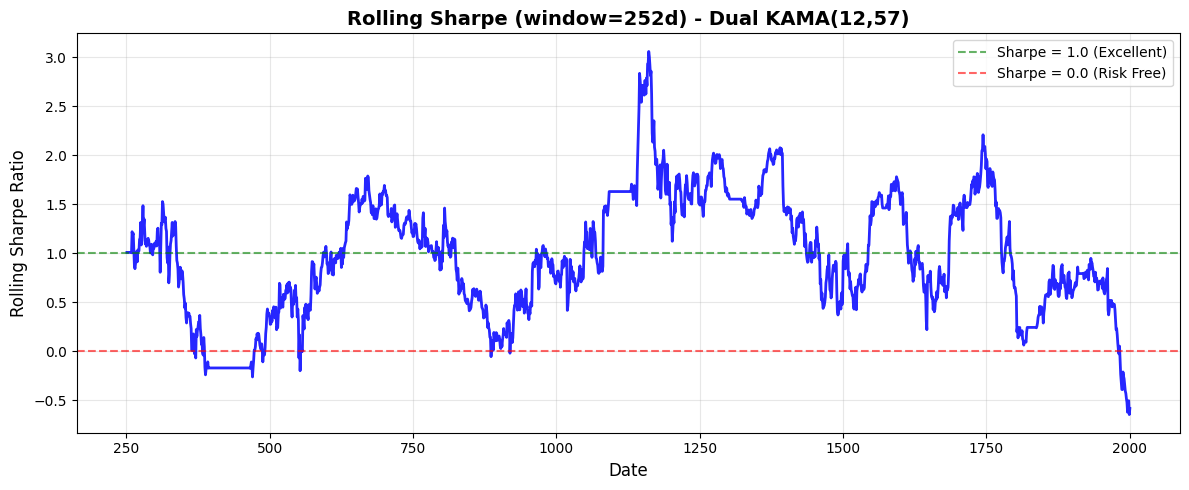

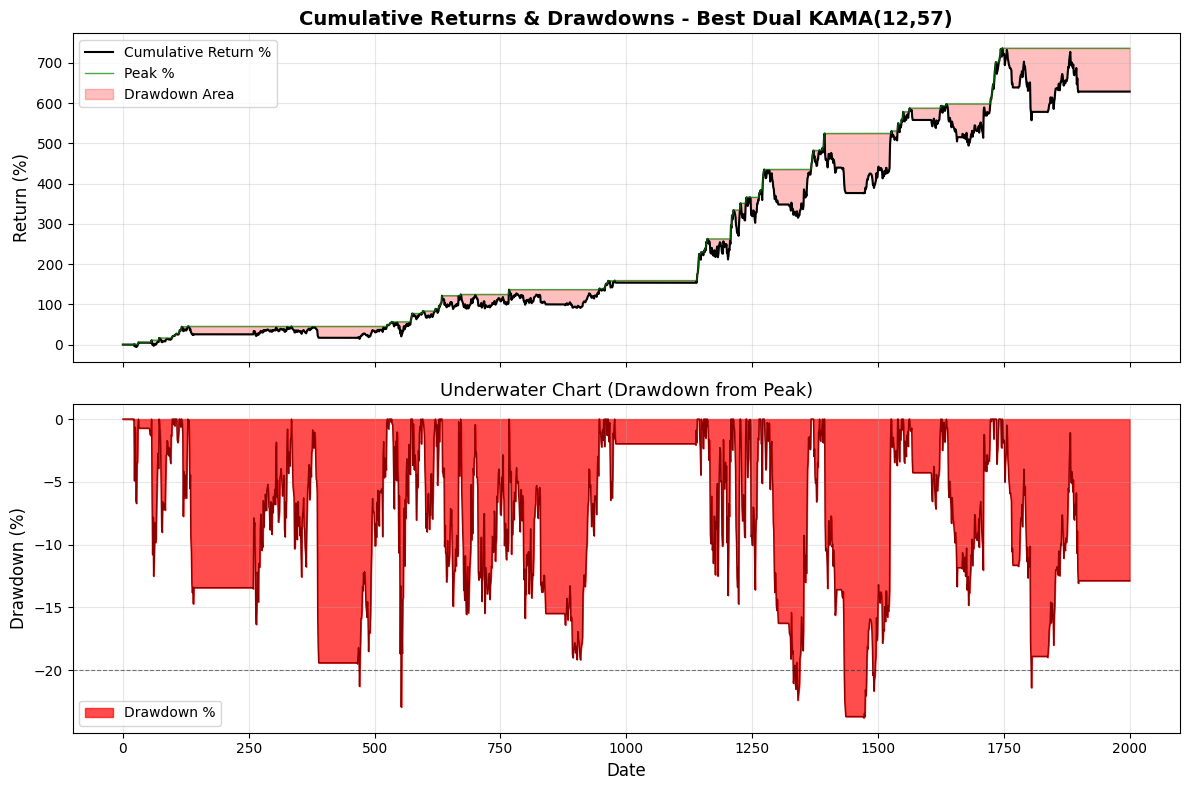

✅ Rolling Sharpe and Drawdown analysis complete for Dual KAMA strategy: 12 / 57


In [12]:
# FULL-SAMPLE ROLLING SHARPE + DRAWDOWNS - BEST DUAL KAMA STRATEGY

# 1. Retrieve Best Parameters (Priority: OOS Globals > In-Sample Fallback)
if 'BEST_KAMA_FAST' in globals() and 'BEST_KAMA_SLOW' in globals():
    k_fast = BEST_KAMA_FAST
    k_slow = BEST_KAMA_SLOW
    print(f"Visualizing Best OOS Strategy: KAMA({k_fast}) x KAMA({k_slow})")
elif not results_df.empty:
    best = results_df.loc[results_df['sharpe_ratio'].idxmax()]
    k_fast, k_slow = int(best['kama_fast']), int(best['kama_slow'])
    print(f"Visualizing Best IS Strategy: KAMA({k_fast}) x KAMA({k_slow})")
else:
    print("No results to visualize.")
    k_fast, k_slow = None, None

if k_fast is not None:
    # 2. Build full-sample Dual KAMA signals
    # Ensure we use full_close (defined in previous Full Sample cell)
    close_np = full_close.to_numpy()
    
    # Calculate Indicators (Numba Engine)
    kama_fast_np = get_kama_nb(close_np, window=k_fast)
    kama_slow_np = get_kama_nb(close_np, window=k_slow)
    
    # Convert to Series for VectorBT
    kama_fast_full = pd.Series(kama_fast_np, index=full_close.index)
    kama_slow_full = pd.Series(kama_slow_np, index=full_close.index)
    
    # Dual KAMA crossover signals (RAW)
    entries_raw = kama_fast_full.vbt.crossed_above(kama_slow_full)
    exits_raw = kama_fast_full.vbt.crossed_below(kama_slow_full)
    
    # ⚠️ FIX LOOKAHEAD BIAS: Shift signals by 1 bar
    entries_full = entries_raw.shift(1).fillna(False).to_numpy(dtype=bool)
    exits_full = exits_raw.shift(1).fillna(False).to_numpy(dtype=bool)

    price_full = full_close.to_numpy(dtype=float)

    # 3. Run Portfolio
    pf_full = vbt.Portfolio.from_signals(
        close=price_full,
        entries=entries_full,
        exits=exits_full,
        init_cash=100_000,
        fees=0.0005,
        slippage=0.0005,
        freq=FREQ
    )

    # Compute returns
    ret = pf_full.returns()

    # --- VISUALIZATION 1: Rolling Sharpe ---
    # 252-day window (approx 1 trading year)
    rolling_window = max(20, min(252, max(1, len(ret) // 4)))
    
    if len(ret) > rolling_window:
        # Calculate Rolling Sharpe
        rolling_sharpe = ret.rolling(window=rolling_window).apply(
            lambda x: (x.mean() * 252) / (x.std() * np.sqrt(252)) if x.std() and x.std() != 0 else np.nan,
            raw=False
        )

        plt.figure(figsize=(12, 5))
        plt.plot(rolling_sharpe.index, rolling_sharpe.values, linewidth=2, color='blue', alpha=0.85)
        plt.axhline(y=1.0, color='green', linestyle='--', alpha=0.6, label='Sharpe = 1.0 (Excellent)')
        plt.axhline(y=0.0, color='red', linestyle='--', alpha=0.6, label='Sharpe = 0.0 (Risk Free)')
        
        plt.title(f'Rolling Sharpe (window={rolling_window}d) - Dual KAMA({k_fast},{k_slow})', fontsize=14, fontweight='bold')
        plt.xlabel('Date', fontsize=12)
        plt.ylabel('Rolling Sharpe Ratio', fontsize=12)
        plt.grid(True, alpha=0.3)
        plt.legend(loc='best')
        plt.tight_layout()
        plt.show()
    else:
        print("⚠️ Not enough data for rolling Sharpe calculation.")

    # --- VISUALIZATION 2: Drawdowns (Underwater) ---
    eq = (1 + ret).cumprod()
    peak = eq.cummax()
    dd = (eq - peak) / peak

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    # Plot 1: Equity Curve & Drawdown Areas
    ax1.plot(eq.index, (eq - 1) * 100, color='black', linewidth=1.5, label='Cumulative Return %')
    ax1.plot(peak.index, (peak - 1) * 100, color='green', linewidth=1.0, alpha=0.7, label='Peak %')
    ax1.fill_between(eq.index, (eq - 1) * 100, (peak - 1) * 100, color='red', alpha=0.25, label='Drawdown Area')
    
    ax1.set_title(f'Cumulative Returns & Drawdowns - Best Dual KAMA({k_fast},{k_slow})', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Return (%)', fontsize=12)
    ax1.grid(True, alpha=0.3)
    ax1.legend(loc='upper left')

    # Plot 2: Underwater Chart
    ax2.fill_between(dd.index, dd * 100, 0, color='red', alpha=0.7, label='Drawdown %')
    ax2.plot(dd.index, dd * 100, color='darkred', linewidth=1)
    ax2.axhline(y=-20, color='black', linestyle='--', alpha=0.5, linewidth=0.8) # Reference line at -20%
    
    ax2.set_title('Underwater Chart (Drawdown from Peak)', fontsize=13)
    ax2.set_xlabel('Date', fontsize=12)
    ax2.set_ylabel('Drawdown (%)', fontsize=12)
    ax2.grid(True, alpha=0.3)
    ax2.legend(loc='lower left')

    plt.tight_layout()
    plt.show()
    
    print(f"✅ Rolling Sharpe and Drawdown analysis complete for Dual KAMA strategy: {k_fast} / {k_slow}")

Visualizing Best OOS Strategy: KAMA(12) x KAMA(57)


C:\Users\clanf\AppData\Local\Temp\ipykernel_10764\927447714.py:32: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`

C:\Users\clanf\AppData\Local\Temp\ipykernel_10764\927447714.py:33: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



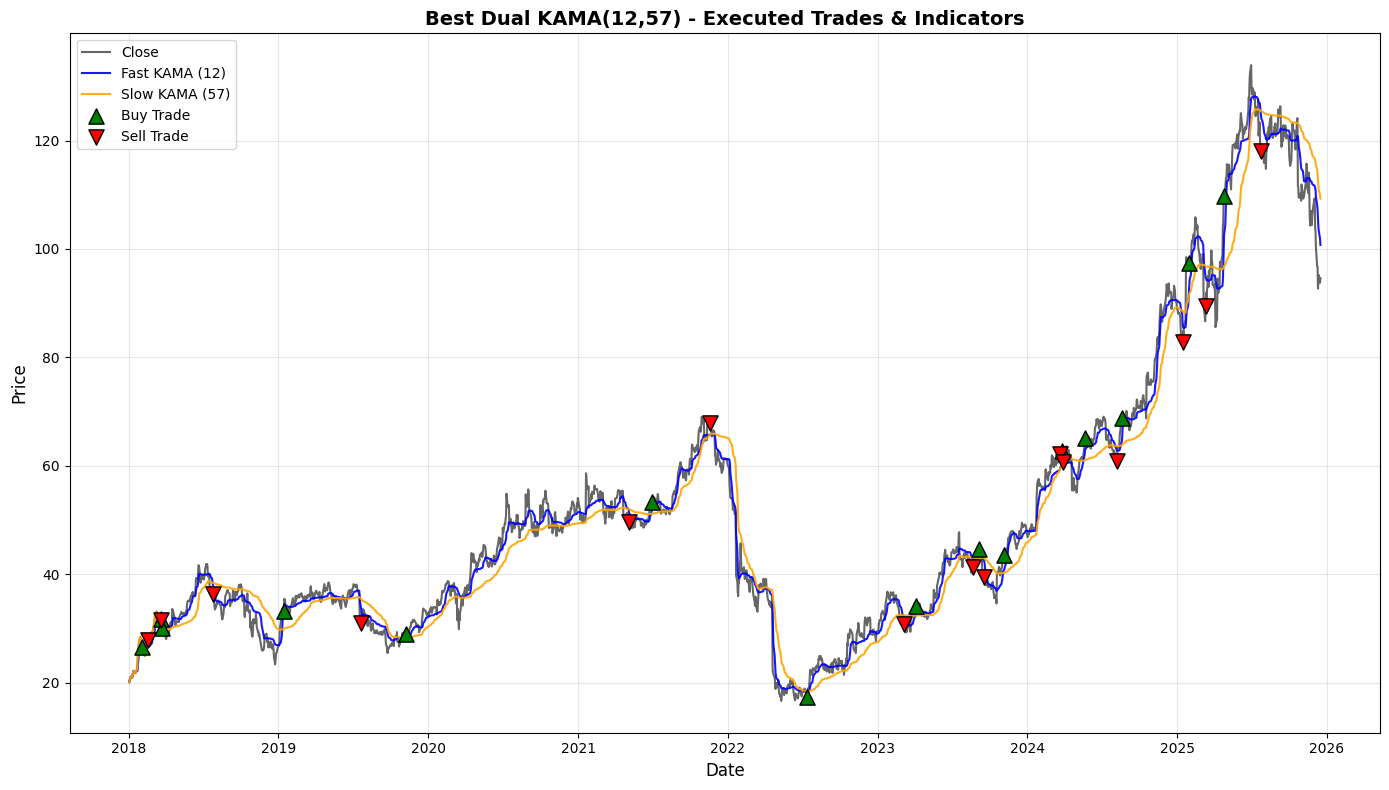

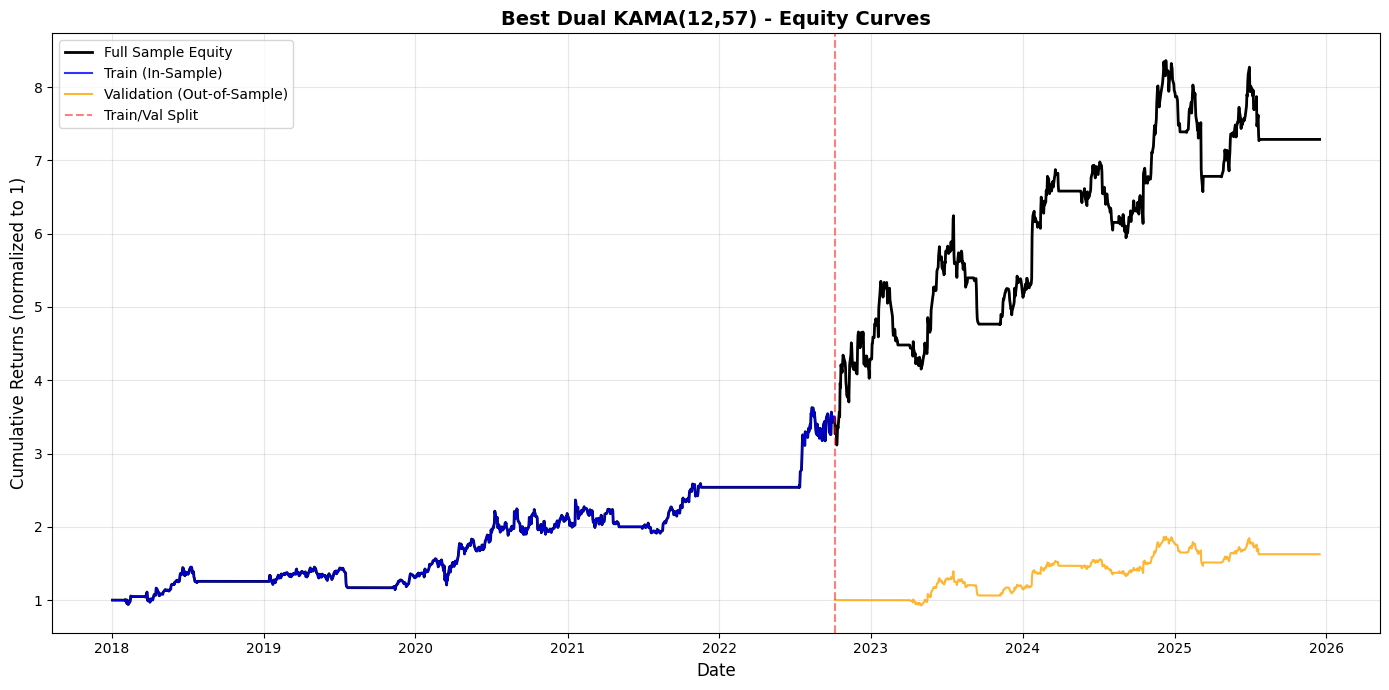

Visualizations complete. Chart shows exactly 15 trades.


In [13]:
# STEP 5C: VISUALS ONLY (Signals + Equity Curves) - BEST DUAL KAMA STRATEGY

# 1. Retrieve Best OOS Parameters (Priority: OOS Globals > In-Sample Fallback)
if 'BEST_KAMA_FAST' in globals() and 'BEST_KAMA_SLOW' in globals():
    k_fast = BEST_KAMA_FAST
    k_slow = BEST_KAMA_SLOW
    print(f"Visualizing Best OOS Strategy: KAMA({k_fast}) x KAMA({k_slow})")
elif not results_df.empty:
    best = results_df.loc[results_df['sharpe_ratio'].idxmax()]
    k_fast, k_slow = int(best['kama_fast']), int(best['kama_slow'])
    print(f"Visualizing Best IS Strategy: KAMA({k_fast}) x KAMA({k_slow})")
else:
    print("No results to visualize.")
    k_fast, k_slow = None, None

if k_fast is not None:
    # 2. Build full sample KAMA Lines
    # Use Numba engine on full_close
    close_np = full_close.to_numpy()
    kama_fast_np = get_kama_nb(close_np, window=k_fast)
    kama_slow_np = get_kama_nb(close_np, window=k_slow)
    
    # Convert to Series for plotting and vectorbt
    kama_fast_full = pd.Series(kama_fast_np, index=full_close.index)
    kama_slow_full = pd.Series(kama_slow_np, index=full_close.index)
    
    # Dual KAMA crossover signals (RAW)
    entries_raw = kama_fast_full.vbt.crossed_above(kama_slow_full)
    exits_raw = kama_fast_full.vbt.crossed_below(kama_slow_full)
    
    # ⚠️ FIX LOOKAHEAD BIAS: Shift signals by 1 bar
    entries_full = entries_raw.shift(1).fillna(False).reindex(full_close.index).fillna(False).to_numpy(dtype=bool)
    exits_full = exits_raw.shift(1).fillna(False).reindex(full_close.index).fillna(False).to_numpy(dtype=bool)

    # 3. Run Portfolio to get CLEAN executed trades
    # (Raw signals can be noisy, portfolio object filters only real entries/exits)
    pf_viz = vbt.Portfolio.from_signals(
        close=full_close,
        entries=entries_full,
        exits=exits_full,
        init_cash=100_000,
        fees=0.0005,
        slippage=0.0005,
        freq=FREQ
    )
    
    # Extract EXACT execution indices
    entry_indices = pf_viz.trades.records['entry_idx']
    exit_indices = pf_viz.trades.records['exit_idx']
    entry_indices = entry_indices[entry_indices >= 0]
    exit_indices = exit_indices[exit_indices >= 0]

    # --- VISUALIZATION 1: Price + KAMA Lines + Executed Trades ---
    fig, ax = plt.subplots(figsize=(14, 8))
    
    # Plot Price
    ax.plot(full_close.index, full_close.values, label='Close', color='black', linewidth=1.5, alpha=0.6)
    
    # Plot KAMA Lines
    ax.plot(full_close.index, kama_fast_full.values, label=f'Fast KAMA ({k_fast})', color='blue', alpha=0.9, linewidth=1.5)
    ax.plot(full_close.index, kama_slow_full.values, label=f'Slow KAMA ({k_slow})', color='orange', alpha=0.9, linewidth=1.5)

    # Plot Executed Trades (using iloc for safe indexing)
    if len(entry_indices) > 0:
        buy_dates = full_close.index[entry_indices]
        buy_prices = full_close.iloc[entry_indices].values
        ax.scatter(buy_dates, buy_prices, marker='^', color='green', s=120, label='Buy Trade', zorder=5, edgecolors='black')

    if len(exit_indices) > 0:
        sell_dates = full_close.index[exit_indices]
        sell_prices = full_close.iloc[exit_indices].values
        ax.scatter(sell_dates, sell_prices, marker='v', color='red', s=120, label='Sell Trade', zorder=5, edgecolors='black')

    ax.set_title(f'Best Dual KAMA({k_fast},{k_slow}) - Executed Trades & Indicators', fontsize=14, fontweight='bold')
    ax.set_xlabel('Date', fontsize=12)
    ax.set_ylabel('Price', fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best')
    plt.tight_layout()
    plt.show()

    # --- VISUALIZATION 2: Equity Curves (Train / Val / Full) ---
    # Create Split Portfolios for visualization
    # Note: We need to respect the original split index
    # Assuming 'split_idx' is available from Data Splitting cell
    
    if 'split_idx' in globals():
        entries_train = entries_full[:split_idx]
        exits_train = exits_full[:split_idx]
        entries_val = entries_full[split_idx:]
        exits_val = exits_full[split_idx:]
        
        pf_train = vbt.Portfolio.from_signals(
            close=train_close.to_numpy(dtype=float),
            entries=entries_train,
            exits=exits_train,
            init_cash=100_000,
            fees=0.0005,
            slippage=0.0005,
            freq=FREQ
        )

        pf_val2 = vbt.Portfolio.from_signals(
            close=val_close.to_numpy(dtype=float),
            entries=entries_val,
            exits=exits_val,
            init_cash=100_000,
            fees=0.0005,
            slippage=0.0005,
            freq=FREQ
        )

        eq_full = (1 + pf_viz.returns()).cumprod()
        eq_train = (1 + pf_train.returns()).cumprod()
        eq_val = (1 + pf_val2.returns()).cumprod()

        fig, ax = plt.subplots(figsize=(14, 7))
        ax.plot(full_close.index, eq_full.values, label='Full Sample Equity', color='black', linewidth=2)
        ax.plot(train_close.index, eq_train.values, label='Train (In-Sample)', color='blue', linewidth=1.5, alpha=0.8)
        ax.plot(val_close.index, eq_val.values, label='Validation (Out-of-Sample)', color='orange', linewidth=1.5, alpha=0.8)
        
        # Add vertical line to show train/val split
        ax.axvline(x=train_close.index[-1], color='red', linestyle='--', alpha=0.5, label='Train/Val Split')

        ax.set_title(f'Best Dual KAMA({k_fast},{k_slow}) - Equity Curves', fontsize=14, fontweight='bold')
        ax.set_xlabel('Date', fontsize=12)
        ax.set_ylabel('Cumulative Returns (normalized to 1)', fontsize=12)
        ax.grid(True, alpha=0.3)
        ax.legend(loc='best')
        plt.tight_layout()
        plt.show()

    print(f"Visualizations complete. Chart shows exactly {len(pf_viz.trades)} trades.")

Visualizing Trade-by-Trade for Best OOS Strategy: KAMA(12) x KAMA(57)
Total trades plotted: 15
Win Rate: 60.0% (9W / 6L)
Avg Win: 32.31% | Avg Loss: -6.21%
Max Win: 76.51% | Max Loss: -11.70%


C:\Users\clanf\AppData\Local\Temp\ipykernel_10764\81067863.py:56: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`

C:\Users\clanf\AppData\Local\Temp\ipykernel_10764\81067863.py:57: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



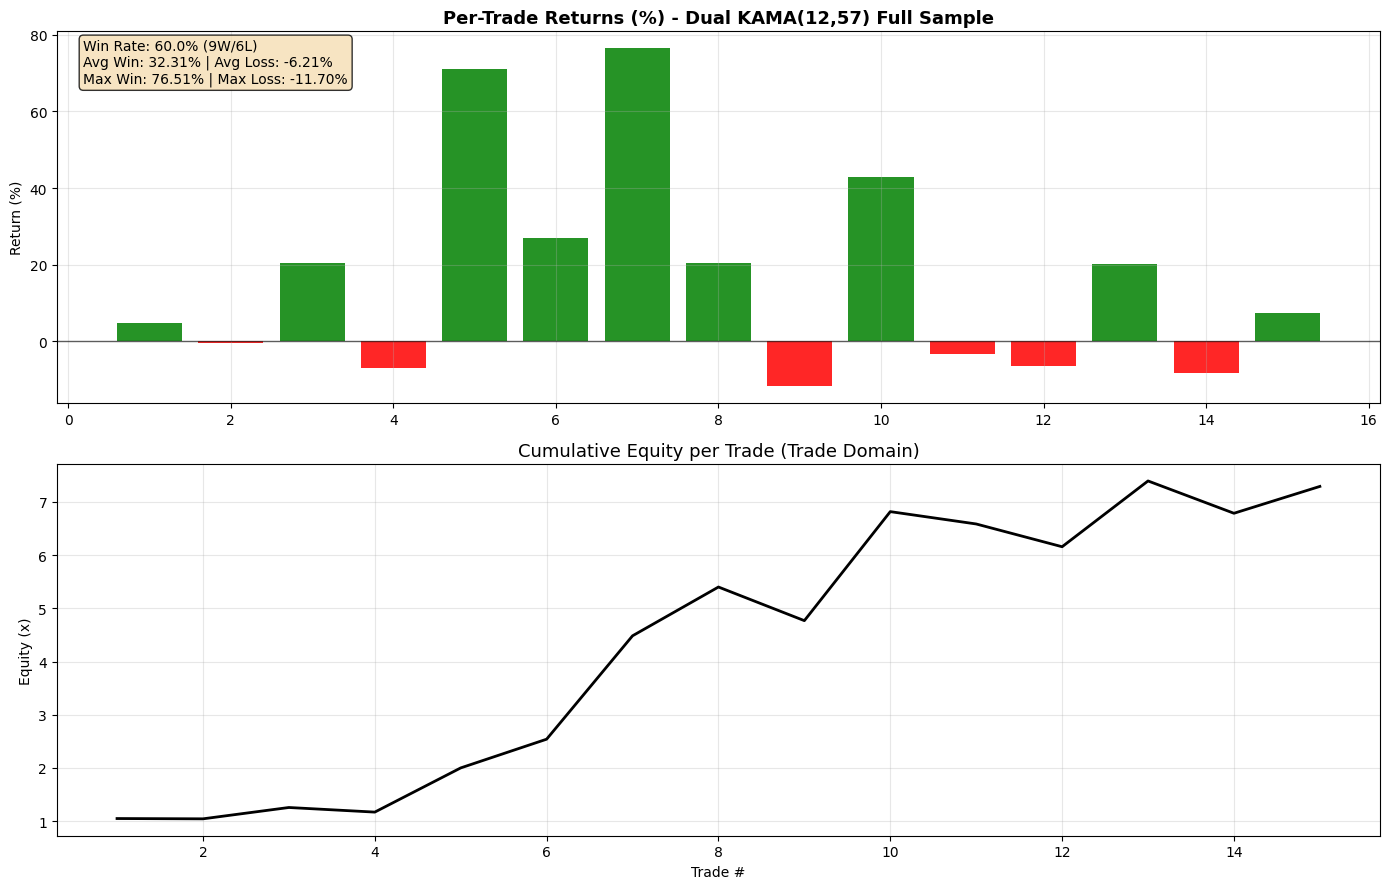

In [14]:
# FULL-SAMPLE TRADE-BY-TRADE RETURNS (BAR) + CUMULATIVE PER-TRADE EQUITY — ALL TRADES (DUAL KAMA)

if 'FREQ' not in globals():
    FREQ = "1D"

# 1. Resolve full close series
if 'close' in globals() and hasattr(close, 'index'):
    full_close = close.astype(float)
else:
    if isinstance(stock_data.columns, pd.MultiIndex):
        if ('Close', TICKER) in stock_data.columns:
            full_close = stock_data[('Close', TICKER)].astype(float).rename(TICKER)
        else:
            found = None
            for col in stock_data.columns:
                if isinstance(col, tuple) and ('Close' in col):
                    found = col; break
            if found is None:
                for col in stock_data.columns:
                    if 'Close' in str(col):
                        found = col; break
            if found is None:
                raise KeyError("Could not find a 'Close' column for full-sample trade plot.")
            full_close = stock_data[found].astype(float).rename(TICKER)
    else:
        full_close = stock_data['Close'].astype(float).rename(TICKER)

# 2. Retrieve Best OOS Parameters (Priority: OOS Globals > In-Sample Fallback)
if 'BEST_KAMA_FAST' in globals() and 'BEST_KAMA_SLOW' in globals():
    k_fast_period = BEST_KAMA_FAST
    k_slow_period = BEST_KAMA_SLOW
    print(f"Visualizing Trade-by-Trade for Best OOS Strategy: KAMA({k_fast_period}) x KAMA({k_slow_period})")
elif 'results_df' in globals() and not results_df.empty:
    best = results_df.loc[results_df['sharpe_ratio'].idxmax()]
    k_fast_period = int(best['kama_fast'])
    k_slow_period = int(best['kama_slow'])
    print(f"Visualizing Trade-by-Trade for Best IS Strategy: KAMA({k_fast_period}) x KAMA({k_slow_period})")
else:
    raise ValueError("results_df is empty or missing. Run the grid search first.")

# 3. Indicators (Using Numba Engine)
close_np = full_close.to_numpy()
kama_fast_np = get_kama_nb(close_np, window=k_fast_period)
kama_slow_np = get_kama_nb(close_np, window=k_slow_period)

# Convert to Series for VectorBT
kama_fast = pd.Series(kama_fast_np, index=full_close.index)
kama_slow = pd.Series(kama_slow_np, index=full_close.index)

# 4. Signals (Dual KAMA Crossover)
entries_raw = kama_fast.vbt.crossed_above(kama_slow)
exits_raw = kama_fast.vbt.crossed_below(kama_slow)

# ⚠️ FIX LOOKAHEAD BIAS: Shift signals by 1 bar
# Convert to plain arrays AND shift
entries_shifted = pd.Series(np.asarray(entries_raw).ravel(), index=full_close.index, dtype=bool).shift(1).fillna(False)
exits_shifted = pd.Series(np.asarray(exits_raw).ravel(), index=full_close.index, dtype=bool).shift(1).fillna(False)

entries_full = pd.Series(np.asarray(entries_shifted).ravel(), index=full_close.index, dtype=bool)
exits_full = pd.Series(np.asarray(exits_shifted).ravel(), index=full_close.index, dtype=bool)

# 5. Backtest
pf_full = vbt.Portfolio.from_signals(
    close=full_close.to_numpy(dtype=float),
    entries=entries_full,
    exits=exits_full,
    init_cash=100_000,
    fees=0.0005,
    slippage=0.0005,
    freq=FREQ
)

# 6. Trade-by-trade returns (ALL trades)
trades = pf_full.trades
trade_returns = trades.returns.values if hasattr(trades.returns, 'values') else np.asarray(trades.returns)
trade_returns = np.asarray(trade_returns).ravel()  # ensure 1D

if trade_returns.size == 0:
    print("No trades to plot.")
else:
    # Calculate statistics
    winning_trades = trade_returns[trade_returns > 0]
    losing_trades = trade_returns[trade_returns < 0]
    
    total_trades = len(trade_returns)
    win_count = len(winning_trades)
    loss_count = len(losing_trades)
    win_rate = (win_count / total_trades * 100) if total_trades > 0 else 0
    
    avg_win_pct = (winning_trades.mean() * 100) if len(winning_trades) > 0 else 0
    avg_loss_pct = (losing_trades.mean() * 100) if len(losing_trades) > 0 else 0
    max_win_pct = (winning_trades.max() * 100) if len(winning_trades) > 0 else 0
    max_loss_pct = (losing_trades.min() * 100) if len(losing_trades) > 0 else 0
    
    print(f"Total trades plotted: {total_trades}")
    print(f"Win Rate: {win_rate:.1f}% ({win_count}W / {loss_count}L)")
    print(f"Avg Win: {avg_win_pct:.2f}% | Avg Loss: {avg_loss_pct:.2f}%")
    print(f"Max Win: {max_win_pct:.2f}% | Max Loss: {max_loss_pct:.2f}%")
    
    equity_per_trade = np.cumprod(1.0 + trade_returns)

    fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=False)

    # Per-trade returns (%), all trades
    x = np.arange(1, trade_returns.size + 1)
    colors = np.where(trade_returns >= 0, 'green', 'red')
    axes[0].bar(x, trade_returns * 100.0, color=colors, alpha=0.85, width=0.8)
    axes[0].axhline(0, color='black', linewidth=1, alpha=0.6)
    
    # Add statistics text box on the chart
    stats_text = (
        f'Win Rate: {win_rate:.1f}% ({win_count}W/{loss_count}L)\n'
        f'Avg Win: {avg_win_pct:.2f}% | Avg Loss: {avg_loss_pct:.2f}%\n'
        f'Max Win: {max_win_pct:.2f}% | Max Loss: {max_loss_pct:.2f}%'
    )
    axes[0].text(0.02, 0.98, stats_text, transform=axes[0].transAxes,
                 fontsize=10, verticalalignment='top',
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    axes[0].set_title(f'Per-Trade Returns (%) - Dual KAMA({k_fast_period},{k_slow_period}) Full Sample', 
                      fontsize=13, fontweight='bold')
    axes[0].set_ylabel('Return (%)')
    axes[0].grid(True, alpha=0.3)

    # Cumulative equity per trade
    axes[1].plot(x, equity_per_trade, color='black', linewidth=2)
    axes[1].set_title('Cumulative Equity per Trade (Trade Domain)', fontsize=13)
    axes[1].set_xlabel('Trade #')
    axes[1].set_ylabel('Equity (x)')
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

🔬 PARAMETER SENSITIVITY ANALYSIS - Base: KAMA(12) x KAMA(57)
IS Sharpe: 1.166 | OOS Sharpe: 1.329

🔄 Testing 41 parameter variations...


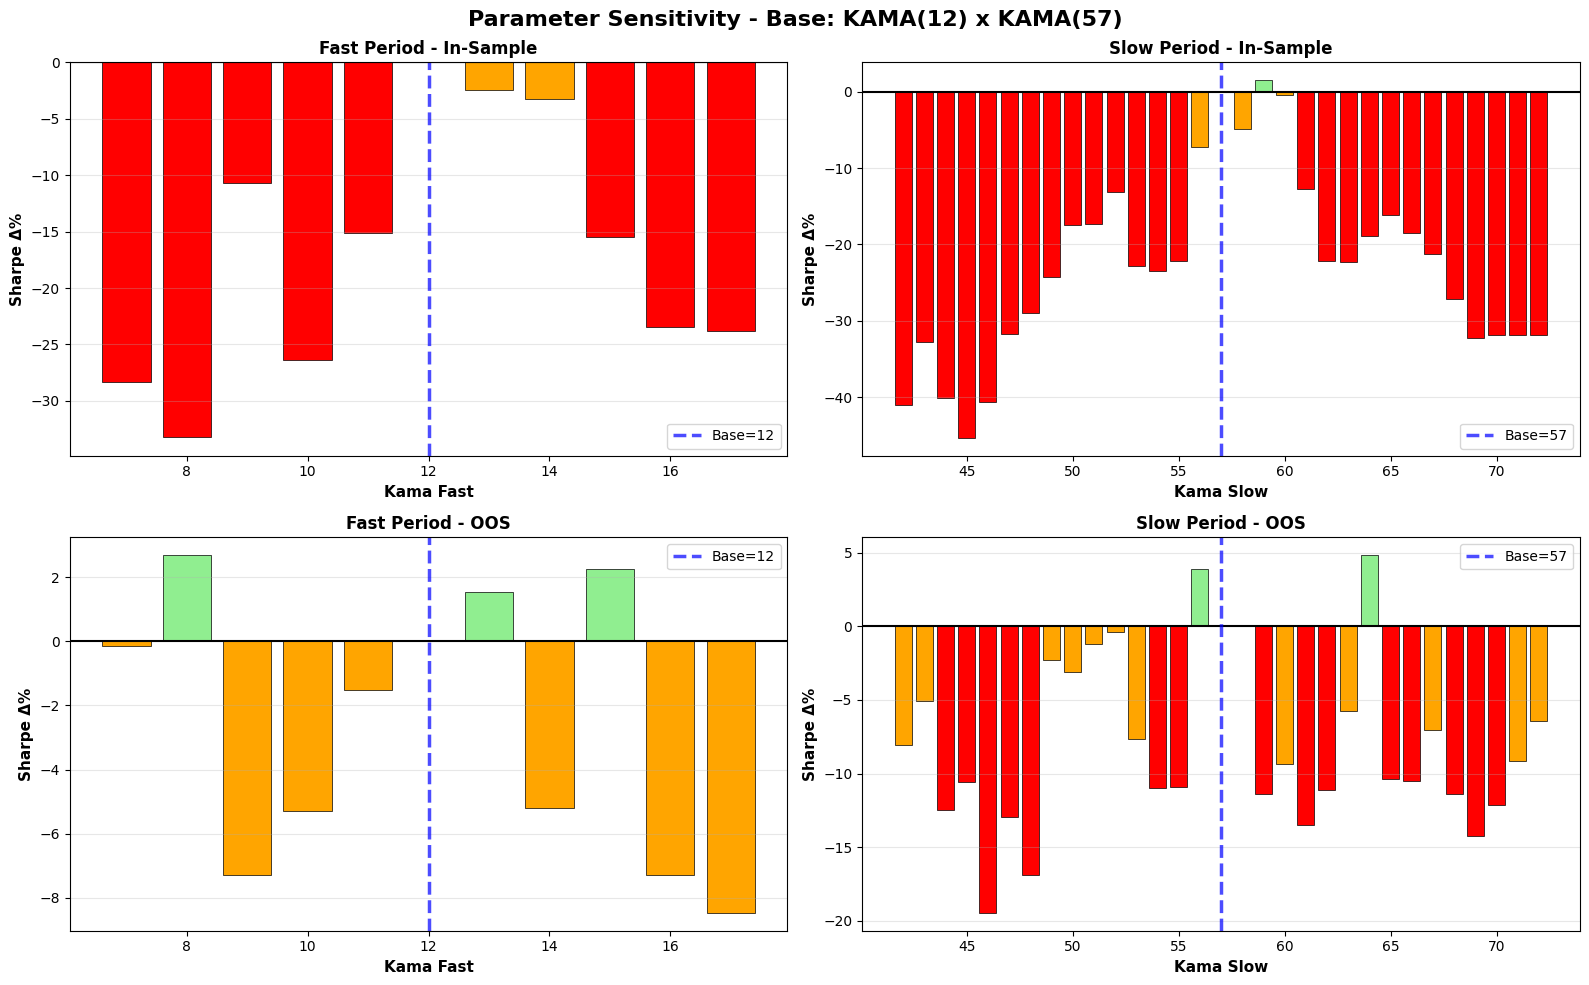


📋 SENSITIVITY SUMMARY (Robustness Check)
Parameter      IS Range IS Max Δ% OOS Max Δ% Sensitivity
KAMA Fast 0.779 - 1.166    -33.2%      -8.5%     ⚠️ HIGH
KAMA Slow 0.637 - 1.184    -45.3%     -19.5%     ⚠️ HIGH

✅ Analysis Complete! Green bars indicate parameter stability.


In [15]:
# COMPACT PARAMETER SENSITIVITY ANALYSIS - DUAL KAMA (HEATMAPS ONLY)

if results_df.empty:
    print("No results available for sensitivity analysis.")
else:
    # 1. Retrieve Best OOS Parameters (Base Case)
    if 'BEST_KAMA_FAST' in globals() and 'BEST_KAMA_SLOW' in globals():
        fast_base, slow_base = BEST_KAMA_FAST, BEST_KAMA_SLOW
        base_is_sharpe = BEST_IS_SHARPE
        base_oos_sharpe = BEST_OOS_SHARPE
        print(f"🔬 PARAMETER SENSITIVITY ANALYSIS - Base: KAMA({fast_base}) x KAMA({slow_base})")
        print(f"IS Sharpe: {base_is_sharpe:.3f} | OOS Sharpe: {base_oos_sharpe:.3f}")
    else:
        # Fallback to IS best
        best = results_df.loc[results_df['sharpe_ratio'].idxmax()]
        fast_base, slow_base = int(best['kama_fast']), int(best['kama_slow'])
        base_is_sharpe = float(best['sharpe_ratio'])
        base_oos_sharpe = np.nan
        print(f"🔬 PARAMETER SENSITIVITY ANALYSIS - Base: KAMA({fast_base}) x KAMA({slow_base})")
        print(f"IS Sharpe: {base_is_sharpe:.3f}")

    # 2. Create sensitivity ranges
    # Fast Period: +/- 5 steps (min 3)
    fast_range = sorted(list(set(range(max(3, fast_base - 5), fast_base + 6))))
    
    # Slow Period: +/- 15 steps (min fast+5)
    slow_range = sorted(list(set(range(max(fast_base + 5, slow_base - 15), slow_base + 16))))
    
    # Generate One-at-a-Time combinations (Ceteris Paribus)
    combos_fast = [(f, slow_base) for f in fast_range]
    combos_slow = [(fast_base, s) for s in slow_range]
    all_combos = list(set(combos_fast + combos_slow)) # Unique combinations

    # Prepare Data for Speed (Numba needs numpy)
    train_close_np = train_close.to_numpy()
    val_close_np = val_close.to_numpy()

    def eval_combo_both(k_fast: int, k_slow: int) -> dict:
        """Evaluate Dual KAMA on both in-sample and out-of-sample"""
        
        # --- IN-SAMPLE ---
        kf_is_np = get_kama_nb(train_close_np, window=k_fast)
        ks_is_np = get_kama_nb(train_close_np, window=k_slow)
        
        kf_is = pd.Series(kf_is_np, index=train_close.index)
        ks_is = pd.Series(ks_is_np, index=train_close.index)
        
        e_raw_is = kf_is.vbt.crossed_above(ks_is)
        x_raw_is = kf_is.vbt.crossed_below(ks_is)
        
        e_is = pd.Series(np.where(e_raw_is.shift(1).isna(), False, e_raw_is.shift(1)), index=train_close.index, dtype=bool)
        x_is = pd.Series(np.where(x_raw_is.shift(1).isna(), False, x_raw_is.shift(1)), index=train_close.index, dtype=bool)
        
        pf_is = vbt.Portfolio.from_signals(close=train_close, entries=e_is, exits=x_is, 
                                           init_cash=100_000, fees=0.0005, slippage=0.0005, freq='D')
        
        # --- OUT-OF-SAMPLE ---
        kf_oos_np = get_kama_nb(val_close_np, window=k_fast)
        ks_oos_np = get_kama_nb(val_close_np, window=k_slow)
        
        kf_oos = pd.Series(kf_oos_np, index=val_close.index)
        ks_oos = pd.Series(ks_oos_np, index=val_close.index)
        
        e_raw_oos = kf_oos.vbt.crossed_above(ks_oos)
        x_raw_oos = kf_oos.vbt.crossed_below(ks_oos)
        
        e_oos = pd.Series(np.where(e_raw_oos.shift(1).isna(), False, e_raw_oos.shift(1)), index=val_close.index, dtype=bool)
        x_oos = pd.Series(np.where(x_raw_oos.shift(1).isna(), False, x_raw_oos.shift(1)), index=val_close.index, dtype=bool)
        
        pf_oos = vbt.Portfolio.from_signals(close=val_close, entries=e_oos, exits=x_oos,
                                            init_cash=100_000, fees=0.0005, slippage=0.0005, freq='D')
        
        return {
            'kama_fast': k_fast, 'kama_slow': k_slow,
            'is_sharpe': float(pf_is.sharpe_ratio(freq='D')),
            'oos_sharpe': float(pf_oos.sharpe_ratio(freq='D')),
            'oos_trades': len(pf_oos.trades)
        }

    print(f"\n🔄 Testing {len(all_combos)} parameter variations...")
    
    rows = []
    for combo in all_combos:
        try:
            # Enforce Fast < Slow logic
            if combo[0] < combo[1]:
                rows.append(eval_combo_both(*combo))
        except Exception:
            pass

    if not rows:
        print("❌ No sensitivity results computed.")
    else:
        sens_df = pd.DataFrame(rows)
        
        # Split by parameter variation
        var_fast = sens_df[sens_df['kama_slow'] == slow_base].copy().sort_values('kama_fast')
        var_slow = sens_df[sens_df['kama_fast'] == fast_base].copy().sort_values('kama_slow')
        
        # Calculate degradations
        var_fast['is_sharpe_delta'] = ((var_fast['is_sharpe'] - base_is_sharpe) / abs(base_is_sharpe) * 100)
        var_slow['is_sharpe_delta'] = ((var_slow['is_sharpe'] - base_is_sharpe) / abs(base_is_sharpe) * 100)
        
        if not np.isnan(base_oos_sharpe):
            var_fast['oos_sharpe_delta'] = ((var_fast['oos_sharpe'] - base_oos_sharpe) / abs(base_oos_sharpe) * 100)
            var_slow['oos_sharpe_delta'] = ((var_slow['oos_sharpe'] - base_oos_sharpe) / abs(base_oos_sharpe) * 100)
        
        # CREATE BAR CHARTS
        fig, axes = plt.subplots(2, 2, figsize=(16, 10))
        fig.suptitle(f'Parameter Sensitivity - Base: KAMA({fast_base}) x KAMA({slow_base})', 
                     fontsize=16, fontweight='bold')
        
        def plot_sens_bar(ax, data, x_col, y_col, base_val, title):
            colors = ['red' if x < -10 else 'orange' if x < 0 else 'lightgreen' if x < 10 else 'darkgreen' 
                      for x in data[y_col]]
            ax.bar(data[x_col], data[y_col], color=colors, edgecolor='black', linewidth=0.5)
            ax.axhline(0, color='black', linewidth=1.5)
            ax.axvline(base_val, color='blue', linestyle='--', linewidth=2.5, alpha=0.7, label=f'Base={base_val}')
            ax.set_xlabel(x_col.replace('_', ' ').title(), fontsize=11, fontweight='bold')
            ax.set_ylabel('Sharpe Δ%', fontsize=11, fontweight='bold')
            ax.set_title(title, fontsize=12, fontweight='bold')
            ax.grid(axis='y', alpha=0.3)
            ax.legend(fontsize=10)

        # IN-SAMPLE ROW
        plot_sens_bar(axes[0,0], var_fast, 'kama_fast', 'is_sharpe_delta', fast_base, 'Fast Period - In-Sample')
        plot_sens_bar(axes[0,1], var_slow, 'kama_slow', 'is_sharpe_delta', slow_base, 'Slow Period - In-Sample')
        
        # OUT-OF-SAMPLE ROW
        if not np.isnan(base_oos_sharpe):
            plot_sens_bar(axes[1,0], var_fast, 'kama_fast', 'oos_sharpe_delta', fast_base, 'Fast Period - OOS')
            plot_sens_bar(axes[1,1], var_slow, 'kama_slow', 'oos_sharpe_delta', slow_base, 'Slow Period - OOS')
        else:
            for ax in axes[1, :]: ax.text(0.5, 0.5, "No OOS Data", ha='center', fontsize=14)

        plt.tight_layout()
        plt.show()
        
        # COMPACT SUMMARY TABLE
        print("\n📋 SENSITIVITY SUMMARY (Robustness Check)")
        print("=" * 80)
        
        summary_data = []
        for param_name, variations in [('KAMA Fast', var_fast), ('KAMA Slow', var_slow)]:
            summary_data.append({
                'Parameter': param_name,
                'IS Range': f"{variations['is_sharpe'].min():.3f} - {variations['is_sharpe'].max():.3f}",
                'IS Max Δ%': f"{variations['is_sharpe_delta'].min():.1f}%",
                'OOS Max Δ%': f"{variations['oos_sharpe_delta'].min():.1f}%" if not np.isnan(base_oos_sharpe) else 'N/A',
                'Sensitivity': '⚠️ HIGH' if abs(variations['is_sharpe_delta'].min()) > 30 else '✅ LOW'
            })
        
        summary_df = pd.DataFrame(summary_data)
        print(summary_df.to_string(index=False))
        print("\n✅ Analysis Complete! Green bars indicate parameter stability.")

In [16]:
from pathlib import Path

base_dir = Path("data") / "single_indicator" / "nflx"
base_dir.mkdir(parents=True, exist_ok=True)

print("Directory created (or already existing):", base_dir.resolve())


Directory created (or already existing): C:\Users\clanf\OneDrive\Desktop\algo trading\FTMO_Challenge\data\single_indicator\nflx


In [17]:
# SAVE BEST DUAL KAMA PARAMETERS (OOS) FOR NFLX 
import json
from pathlib import Path
import numpy as np

# --- 1. Identify best OOS strategy (OOS preferred, IS fallback) ---
if 'oos_df_sorted' in globals() and not oos_df_sorted.empty:
    # Caso 1: Uso la strategia migliore fuori campione (più robusta)
    best_strategy_row = oos_df_sorted.iloc[0]
    
    best_params_dkama_nflx = {
        "kama_fast": int(best_strategy_row['Kama_Fast']),
        "kama_slow": int(best_strategy_row['Kama_Slow'])
    }
    
    # Uso metriche OOS per il salvataggio finale
    best_metrics_dkama_nflx = {
        "total_return": float(best_strategy_row['OOS_Return']),
        "sharpe_ratio": float(best_strategy_row['OOS_Sharpe']),
        "max_drawdown": float(best_strategy_row['OOS_MaxDD']),
        "win_rate": float(best_strategy_row['OOS_WinRate']),
        "total_trades": int(best_strategy_row['OOS_Trades'])
    }
    source_label = "BEST Out-of-Sample (OOS)"
    
elif "results_df" in globals() and not results_df.empty:
    # Caso 2: Fallback sulla strategia migliore in-sample (se OOS non è disponibile)
    best_strategy_row = results_df.loc[results_df['sharpe_ratio'].idxmax()]
    
    best_params_dkama_nflx = {
        "kama_fast": int(best_strategy_row["kama_fast"]),
        "kama_slow": int(best_strategy_row["kama_slow"])
    }
    
    # Uso metriche IS per il salvataggio
    best_metrics_dkama_nflx = {
        "total_return": float(best_strategy_row["total_return"]),
        "sharpe_ratio": float(best_strategy_row["sharpe_ratio"]),
        "max_drawdown": float(best_strategy_row["max_drawdown"]),
        "win_rate": float(best_strategy_row["win_rate"]),
        "total_trades": int(best_strategy_row["total_trades"])
    }
    source_label = "BEST In-Sample (IS - OOS non disponibile)"

else:
    raise ValueError("Cannot save parameters. Run the Grid Search and OOS Validation cells first.")


# --- 2. Saving Logic ---
# Base directory: data/single_indicator/nflx
base_dir = Path("data") / "single_indicator" / "nflx" 
base_dir.mkdir(parents=True, exist_ok=True)

# File paths (Naming convention: dkama)
params_path = base_dir / "best_params_dkama_nflx.json"
metrics_path = base_dir / "best_metrics_dkama_nflx.json"

# Save to JSON files
with params_path.open("w") as f:
    json.dump(best_params_dkama_nflx, f, indent=4)

with metrics_path.open("w") as f:
    json.dump(best_metrics_dkama_nflx, f, indent=4)

print(f"Source: {source_label}")
print("Saved best DUAL KAMA NFLX parameters to:", params_path.resolve())
print("Saved best DUAL KAMA NFLX metrics to:", metrics_path.resolve())
print("Params:", best_params_dkama_nflx)

Source: BEST Out-of-Sample (OOS)
Saved best DUAL KAMA NFLX parameters to: C:\Users\clanf\OneDrive\Desktop\algo trading\FTMO_Challenge\data\single_indicator\nflx\best_params_dkama_nflx.json
Saved best DUAL KAMA NFLX metrics to: C:\Users\clanf\OneDrive\Desktop\algo trading\FTMO_Challenge\data\single_indicator\nflx\best_metrics_dkama_nflx.json
Params: {'kama_fast': 12, 'kama_slow': 57}


In [18]:
import os
import pandas as pd
import numpy as np
# Non serve importare vbt qui se usiamo pf_full che esiste già

# ============================================================
# EXPORT DATA FOR ALLOCATION TEMPLATE (NFLX KAMA)
# ============================================================

# --- CONFIGURAZIONE ---
CURRENT_TICKER = "NFLX"
OUTPUT_FOLDER = "ftmo_dataset"

# 1. Estrazione Posizione Direttamente dal Portafoglio
# pf_full contiene già la logica esatta del backtest
amzn_position_series = pf_full.position_mask().astype(int)

# Se per caso amzn_position_series è un DataFrame, lo appiattiamo a Series
if isinstance(amzn_position_series, pd.DataFrame):
    amzn_position_series = amzn_position_series.iloc[:, 0]

# 2. Costruzione DataFrame Export
export_df = pd.DataFrame(index=full_close.index)

# A. Prezzo (Close)
export_df[f'{CURRENT_TICKER}_Close'] = full_close

# B. Rendimenti (Return) - QUESTA RIGA CALCOLA I RETURN
export_df[f'{CURRENT_TICKER}_Return'] = full_close.pct_change()

# C. Posizione (0 o 1)
export_df[f'{CURRENT_TICKER}_Position'] = amzn_position_series

# 3. Pulizia e Salvataggio
if not os.path.exists(OUTPUT_FOLDER):
    os.makedirs(OUTPUT_FOLDER)

# Rimuovi NaN iniziali (la prima riga sarà NaN per via del pct_change)
export_df.dropna(inplace=True)

filename = f"{OUTPUT_FOLDER}/{CURRENT_TICKER}_returns.csv"
export_df.to_csv(filename)

print("="*60)
print(f"✅ EXPORT COMPLETATO: {CURRENT_TICKER} (Dual KAMA Strategy)")
print(f"📍 File salvato in: {filename}")
print(f"📊 Giorni Totali: {len(export_df)}")
print("-" * 60)
print("Anteprima Dati COMPLETA (Ora dovresti vedere Close, Return e Position):")
# Ho rimosso il filtro delle colonne, ora stampa TUTTO il dataframe
print(export_df.tail())
print("="*60)

✅ EXPORT COMPLETATO: NFLX (Dual KAMA Strategy)
📍 File salvato in: ftmo_dataset/NFLX_returns.csv
📊 Giorni Totali: 2000
------------------------------------------------------------
Anteprima Dati COMPLETA (Ora dovresti vedere Close, Return e Position):
            NFLX_Close  NFLX_Return  NFLX_Position
Date                                              
2025-12-10   92.709999    -0.041361              0
2025-12-11   94.089996     0.014885              0
2025-12-12   95.190002     0.011691              0
2025-12-15   93.769997    -0.014918              0
2025-12-16   94.570000     0.008532              0
